<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD_FinalProject/blob/main/Envi_Stress_on_Crop_Yield_SSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impact of Environmental Stress on Crop Yield Across Sub-Saharan Africa

This notebook performs the full analysis pipeline referenced in the project report: database description, exploratory data analysis, genotype clustering, GGE biplot analysis, and cross-crop environmental driver modelling.

## Section 0 — Setup

> **AI prompt used:** *"Set up a Python notebook environment for crop yield analysis: import pandas, numpy, matplotlib, seaborn, scipy.stats, statsmodels, scikit-learn clustering/scaling tools, and suppress warnings. Define a consistent colour palette for the three management conditions (Optimum, Drought, Low-N) and a fixed display order, to be reused across all charts in the notebook."

In [1]:
# ============================================================
# Section 0 (Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Consistent colour palettes used throughout the notebook
mgmt_palette = {'Optimum': 'seagreen', 'Drought': 'firebrick', 'Low-N': 'goldenrod'}
mgmt_order   = ['Optimum', 'Drought', 'Low-N']


## Section 1 — Database Description

> **AI prompt used:** *"Load the merged multi-crop trial dataset and produce a full database description: shape, columns, data types, coverage of crops/countries/regions/years/management conditions, sample sizes per crop, a crop × country and crop × management cross-tabulation, a missing-data audit, descriptive statistics for grain yield and the six environmental/soil variables (overall, by crop, and by crop × management), and a check that confirms the replicate structure is balanced."

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/olawaleaboderin/AVCAD_FinalProject/main/master_crop_dataset.csv')

In [4]:
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

Dataset shape (rows, columns): (90762, 57)

Column names:
['sn', 'YEAR', 'Country', 'region', 'agro_ecological_zone', 'season', 'environment_condition', 'elevation', 'soil_pH', 'soil_N_content', 'soil_P_content', 'soil_K_content', 'mean_temperature', 'rainfall_mm', 'Crop', 'Scientific_name', 'soil_type', 'ENTRY', 'Pedigree', 'Name', 'breeding_institution', 'maturity_group', 'rep', 'days_to_anthesis', 'Days_to_silking', 'anthesis_silking_interval', 'plant_height', 'ear_height', 'husk_cover', 'plant_aspect', 'field_weight', 'ear_harvested', 'ear_per_plant', 'ear_aspect', 'grain_moisture', 'grain_yield', 'staygreen', 'canopy_height', 'branches_per_plant', 'peduncles_per_plant', 'pods_per_plant', 'seeds_per_plot', 'seed_100_weight', 'dry_matter', 'harvest_index', 'fodder_yield', 'grains_per_panicle', 'panicle_width', 'panicle_length', 'panicle_number', 'seed_1000_weight', 'tillers_per_plant', 'leaf_number', 'panicle_harvested', 'leaf_length', 'leaf_width', 'grain_covering']

First 5 rows:


In [5]:
print("\n--- Coverage Summary ---")
print("Crops:", df['Crop'].unique())
print("Countries:", df['Country'].unique())
print("Number of regions:", df['region'].nunique())
print("Regions:", df['region'].unique())
print("Years:", sorted(df['YEAR'].unique()))
print("Management conditions:", df['environment_condition'].unique())
print("Number of unique genotypes (overall):", df['Name'].nunique())


--- Coverage Summary ---
Crops: ['Rice' 'Sorghum' 'Maize' 'Cowpea']
Countries: ['Ghana' 'Nigeria' 'Kenya' 'Tanzania' 'Ethiopia']
Number of regions: 17
Regions: ['Damongo' 'Ibadan' 'Ilorin' 'Kiboko' 'Kitale' 'mokwa' 'Nairobi'
 'Nyankpala' 'Omu-Aran' 'Yendi' 'Zaria' 'Morogoro' 'Dodoma' 'Arusha'
 'Bako' 'Hawassa' 'Melkassa']
Years: [np.int64(2020), np.int64(2021), np.int64(2022)]
Management conditions: ['Optimum' 'Low-N' 'Drought']
Number of unique genotypes (overall): 407


In [6]:
print("\n--- Rows per Crop ---")
print(df['Crop'].value_counts())

print("\n--- Genotypes per Crop ---")
print(df.groupby('Crop')['Name'].nunique())

print("\n--- Countries per Crop ---")
print(df.groupby('Crop')['Country'].nunique())

print("\n--- Regions per Crop ---")
print(df.groupby('Crop')['region'].nunique())


--- Rows per Crop ---
Crop
Maize      72522
Sorghum    11880
Rice        3960
Cowpea      2400
Name: count, dtype: int64

--- Genotypes per Crop ---
Crop
Cowpea      50
Maize      237
Rice        60
Sorghum     60
Name: Name, dtype: int64

--- Countries per Crop ---
Crop
Cowpea     2
Maize      5
Rice       3
Sorghum    4
Name: Country, dtype: int64

--- Regions per Crop ---
Crop
Cowpea      8
Maize      17
Rice       11
Sorghum    11
Name: region, dtype: int64


In [7]:
print("\n--- Crop x Country Sample Sizes ---")
print(pd.crosstab(df['Crop'], df['Country']))


--- Crop x Country Sample Sizes ---
Country  Ethiopia  Ghana  Kenya  Nigeria  Tanzania
Crop                                              
Cowpea          0    900      0     1500         0
Maize       12798  12798  12798    21330     12798
Rice            0   1080   1080     1800         0
Sorghum         0   3240   3240     2160      3240


In [8]:
print("\n--- Crop x Management Condition Sample Sizes ---")
print(pd.crosstab(df['Crop'], df['environment_condition']))


--- Crop x Management Condition Sample Sizes ---
environment_condition  Drought  Low-N  Optimum
Crop                                          
Cowpea                       0      0     2400
Maize                    24174  24174    24174
Rice                         0      0     3960
Sorghum                   3960   3960     3960


In [9]:
print("\n--- Missing Values per Column ---")
print(df.isna().sum())

print("\n--- Missing Values (%) per Column ---")
print((df.isna().mean() * 100).round(2))


--- Missing Values per Column ---
sn                               0
YEAR                             0
Country                          0
region                           0
agro_ecological_zone             0
season                           0
environment_condition            0
elevation                        0
soil_pH                          1
soil_N_content                   1
soil_P_content                   1
soil_K_content                   1
mean_temperature                 1
rainfall_mm                      1
Crop                             0
Scientific_name                  0
soil_type                        0
ENTRY                            0
Pedigree                     18240
Name                             0
breeding_institution             0
maturity_group                6360
rep                              0
days_to_anthesis                 0
Days_to_silking              18240
anthesis_silking_interval    18240
plant_height                  2400
ear_height          

In [10]:
key_vars = ['grain_yield', 'rainfall_mm', 'mean_temperature', 'soil_pH',
            'soil_N_content', 'soil_P_content', 'soil_K_content']

print("\n--- Descriptive Statistics: Key Variables (overall) ---")
print(df[key_vars].describe().round(2))


--- Descriptive Statistics: Key Variables (overall) ---
       grain_yield  rainfall_mm  mean_temperature   soil_pH  soil_N_content  \
count     90762.00     90761.00          90761.00  90761.00        90761.00   
mean       1810.99       899.42             24.75      6.22            0.81   
std        2287.77       278.39              3.55      0.36            0.42   
min           0.00       300.00             18.00      5.70            0.20   
25%         267.47       650.00             21.50      6.00            0.50   
50%         994.82       950.00             26.00      6.20            0.70   
75%        2429.66      1100.00             28.00      6.40            1.10   
max       19994.43      1300.00             30.50      7.20            1.80   

       soil_P_content  soil_K_content  
count        90761.00        90761.00  
mean             9.14            0.66  
std              2.18            0.17  
min              6.00            0.50  
25%              7.00          

In [11]:
print("\n--- Grain Yield Summary by Crop ---")
print(df.groupby('Crop')['grain_yield'].describe().round(2))


--- Grain Yield Summary by Crop ---
           count     mean      std    min      25%      50%      75%       max
Crop                                                                          
Cowpea    2400.0  2544.29  1769.45   0.18  1121.39  2286.90  3716.35  10910.00
Maize    72522.0  1424.88  2024.10   0.00   197.26   737.49  1805.97  19994.43
Rice      3960.0  3795.74  2691.93  11.97  1700.12  3404.33  5330.71  15617.74
Sorghum  11880.0  3358.30  2683.97  90.61  1173.12  2765.44  4828.87  15740.30


In [12]:
print("\n--- Grain Yield Summary by Crop and Management Condition ---")
print(df.groupby(['Crop', 'environment_condition'])['grain_yield'].describe().round(2))


--- Grain Yield Summary by Crop and Management Condition ---
                                 count     mean      std     min      25%  \
Crop    environment_condition                                               
Cowpea  Optimum                 2400.0  2544.29  1769.45    0.18  1121.39   
Maize   Drought                24174.0   837.44   966.61    0.00   186.52   
        Low-N                  24174.0   394.33   464.33    1.48    79.94   
        Optimum                24174.0  3042.87  2667.61  244.71  1324.76   
Rice    Optimum                 3960.0  3795.74  2691.93   11.97  1700.12   
Sorghum Drought                 3960.0  4105.20  2216.01  349.64  2496.23   
        Low-N                   3960.0   922.11   536.52   90.61   503.73   
        Optimum                 3960.0  5047.60  2658.43  554.98  3101.05   

                                   50%      75%       max  
Crop    environment_condition                              
Cowpea  Optimum                2286.90  3716.35

In [13]:
print("\n--- Replicate values present ---")
print(df['rep'].unique())

print("\n--- Rows per genotype, by crop (confirms balance) ---")
for crop in df['Crop'].unique():
    sub = df[df['Crop'] == crop]
    print(f"\n{crop}:")
    print(sub.groupby('Name').size().describe())


--- Replicate values present ---
[1 2]

--- Rows per genotype, by crop (confirms balance) ---

Rice:
count    60.0
mean     66.0
std       0.0
min      66.0
25%      66.0
50%      66.0
75%      66.0
max      66.0
dtype: float64

Sorghum:
count     60.0
mean     198.0
std        0.0
min      198.0
25%      198.0
50%      198.0
75%      198.0
max      198.0
dtype: float64

Maize:
count    237.0
mean     306.0
std        0.0
min      306.0
25%      306.0
50%      306.0
75%      306.0
max      306.0
dtype: float64

Cowpea:
count    50.0
mean     48.0
std       0.0
min      48.0
25%      48.0
50%      48.0
75%      48.0
max      48.0
dtype: float64


## Section 2 — Exploratory Data Analysis: Maize

> **AI prompt used:** *"For the Maize subset, run a complete stress-response EDA pipeline: (1) one-way ANOVA and Tukey HSD comparing grain yield across Optimum/Drought/Low-N; (2) repeat the comparison within each country; (3) yield by region and by year; (4) a two-way ANOVA testing Region × Management interaction with effect sizes; (5) Ward-linkage hierarchical clustering of all 237 genotypes based on their mean yield across every region × management combination, including a dendrogram, a comparison of candidate cluster counts, cluster yield profiles, and a table of the top-performing genotypes per cluster for later use in a variety dashboard."

In [14]:
# ============================================================
#  SECTION 2 Exploratory data analysis
# ============================================================
# ----------- Maize ------------------------------------------
print("\n" + "="*60)
print("SECTION 1 — MAIZE")
print("="*60)

maize = df[df['Crop'] == 'Maize'].copy()
print(f"Maize: {maize.shape[0]} rows, {maize['Name'].nunique()} genotypes, "
      f"{maize['region'].nunique()} regions, {maize['Country'].nunique()} countries")


SECTION 1 — MAIZE
Maize: 72522 rows, 237 genotypes, 17 regions, 5 countries



--- 1.1 Yield by Management Condition (all countries combined) ---
                         count    mean     std    min     25%     50%     75%  \
environment_condition                                                           
Drought                24174.0   837.4   966.6    0.0   186.5   481.7  1140.0   
Low-N                  24174.0   394.3   464.3    1.5    79.9   205.5   533.7   
Optimum                24174.0  3042.9  2667.6  244.7  1324.8  2205.1  3742.1   

                           max  
environment_condition           
Drought                 9751.1  
Low-N                   4410.2  
Optimum                19994.4  

% loss Drought vs Optimum: 72.5%
% loss Low-N vs Optimum:   87.0%


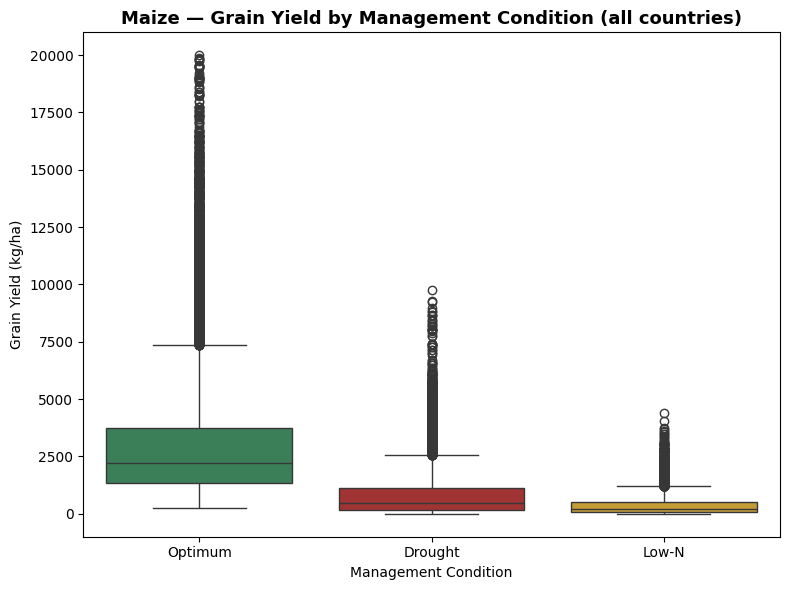

                                sum_sq       df             F  PR(>F)
C(environment_condition)  9.730033e+10      2.0  17656.593262     0.0
Residual                  1.998155e+11  72519.0           NaN     NaN
Effect size (eta-squared) = 0.3275

Tukey HSD:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj   lower     upper   reject
----------------------------------------------------------
Drought   Low-N -443.1138   0.0 -478.5005 -407.7271   True
Drought Optimum  2205.424   0.0 2170.0373 2240.8108   True
  Low-N Optimum 2648.5378   0.0 2613.1511 2683.9246   True
----------------------------------------------------------


In [15]:
print("\n--- 1.1 Yield by Management Condition (all countries combined) ---")

desc = maize.groupby('environment_condition')['grain_yield'].describe()
print(desc.round(1))

means = maize.groupby('environment_condition')['grain_yield'].mean()
print(f"\n% loss Drought vs Optimum: {(1 - means['Drought']/means['Optimum'])*100:.1f}%")
print(f"% loss Low-N vs Optimum:   {(1 - means['Low-N']/means['Optimum'])*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=maize, x='environment_condition', y='grain_yield',
            order=mgmt_order, palette=mgmt_palette, ax=ax)
ax.set_title('Maize — Grain Yield by Management Condition (all countries)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Management Condition')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

model = ols('grain_yield ~ C(environment_condition)', data=maize).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
eta_sq = anova_table.loc['C(environment_condition)', 'sum_sq'] / anova_table['sum_sq'].sum()
print(f"Effect size (eta-squared) = {eta_sq:.4f}")

tukey = pairwise_tukeyhsd(maize['grain_yield'], maize['environment_condition'])
print("\nTukey HSD:")
print(tukey)


--- 1.2 Yield by Management Condition — Per Country ---


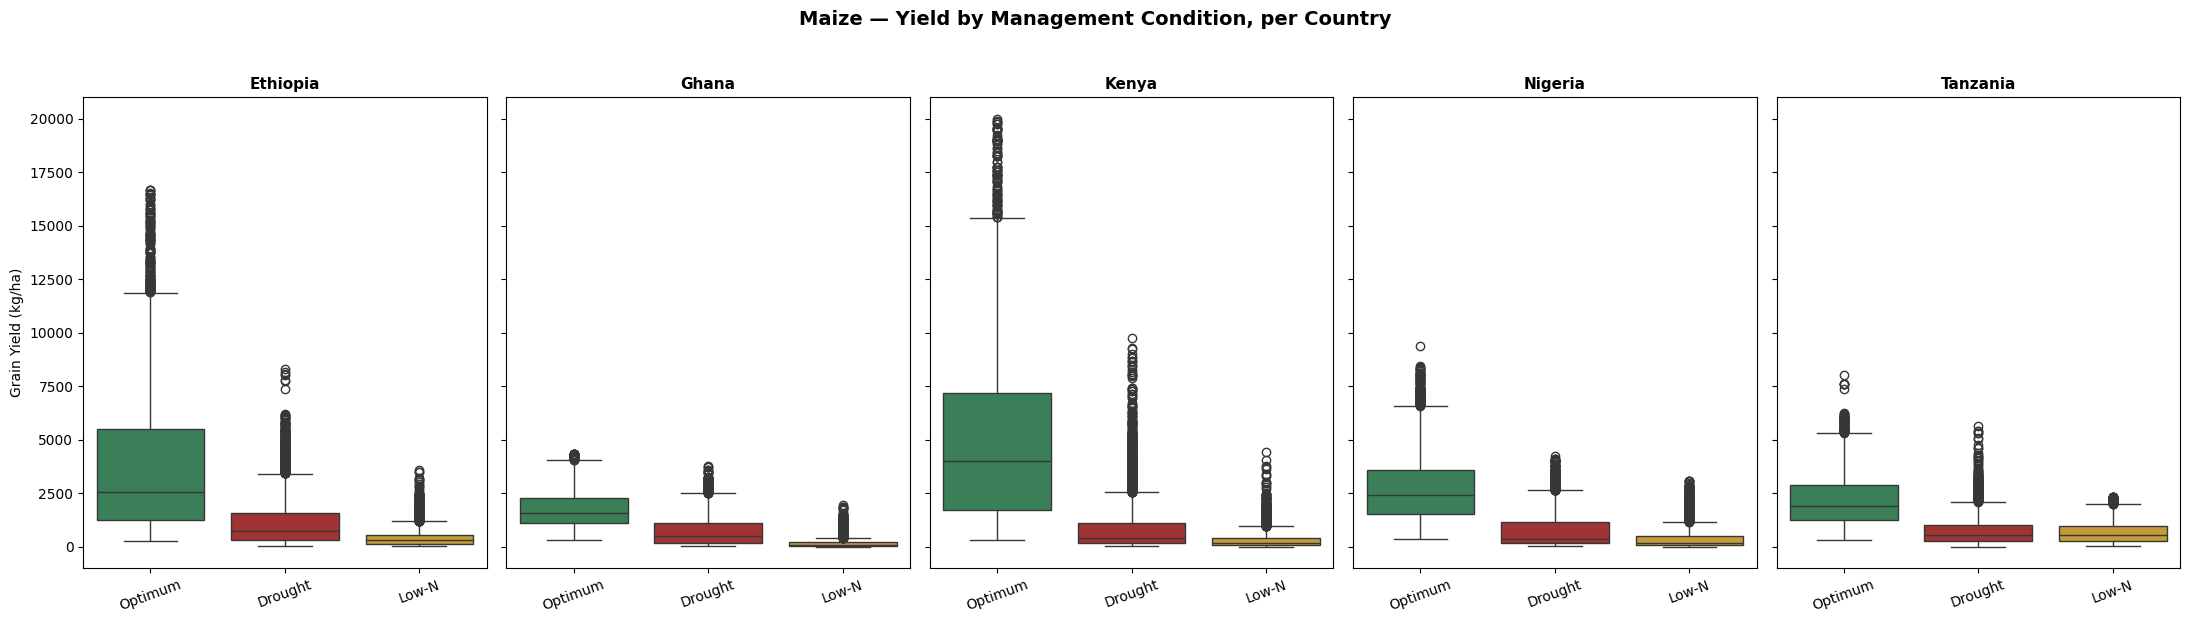


Per-country ANOVA summary:
Country          F-stat      p-value     eta²   % loss Drought   % loss Low-N
------------------------------------------------------------------------------
Ethiopia         3165.7     0.00e+00   0.3310            69.8%          88.8%
Ghana            7037.3     0.00e+00   0.5238            59.5%          90.4%
Kenya            4604.7     0.00e+00   0.4185            81.4%          93.4%
Nigeria         10462.8     0.00e+00   0.4953            72.7%          85.2%
Tanzania         4414.6     0.00e+00   0.4083            66.7%          70.3%


In [16]:
print("\n--- 1.2 Yield by Management Condition — Per Country ---")

countries_maize = sorted(maize['Country'].unique())
fig, axes = plt.subplots(1, len(countries_maize), figsize=(22, 6), sharey=True)
for i, country in enumerate(countries_maize):
    sub = maize[maize['Country'] == country]
    sns.boxplot(data=sub, x='environment_condition', y='grain_yield',
                order=mgmt_order, palette=mgmt_palette, ax=axes[i])
    axes[i].set_title(country, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Grain Yield (kg/ha)' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=20)
plt.suptitle('Maize — Yield by Management Condition, per Country', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nPer-country ANOVA summary:")
print(f"{'Country':<12} {'F-stat':>10} {'p-value':>12} {'eta²':>8} "
      f"{'% loss Drought':>16} {'% loss Low-N':>14}")
print("-" * 78)
for country in countries_maize:
    sub = maize[maize['Country'] == country]
    m = ols('grain_yield ~ C(environment_condition)', data=sub).fit()
    at = sm.stats.anova_lm(m, typ=2)
    f_stat = at.loc['C(environment_condition)', 'F']
    p_val  = at.loc['C(environment_condition)', 'PR(>F)']
    eta    = at.loc['C(environment_condition)', 'sum_sq'] / at['sum_sq'].sum()
    cm = sub.groupby('environment_condition')['grain_yield'].mean()
    loss_drought = (1 - cm['Drought'] / cm['Optimum']) * 100
    loss_lown    = (1 - cm['Low-N']   / cm['Optimum']) * 100
    print(f"{country:<12} {f_stat:>10.1f} {p_val:>12.2e} {eta:>8.4f} "
          f"{loss_drought:>15.1f}% {loss_lown:>13.1f}%")


--- 1.3 Grain Yield by Region ---


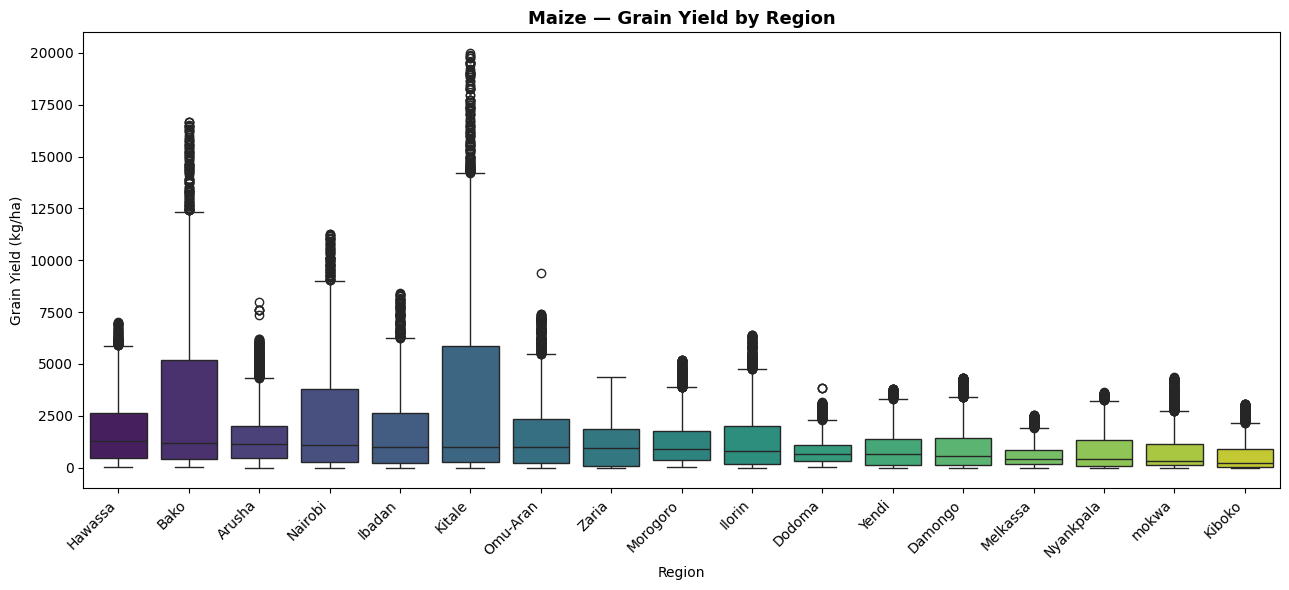

In [17]:
print("\n--- 1.3 Grain Yield by Region ---")

fig, ax = plt.subplots(figsize=(13, 6))
order_region = maize.groupby('region')['grain_yield'].median().sort_values(ascending=False).index
sns.boxplot(data=maize, x='region', y='grain_yield', order=order_region,
            palette='viridis', ax=ax)
ax.set_title('Maize — Grain Yield by Region', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- 1.4 Grain Yield by Year ---


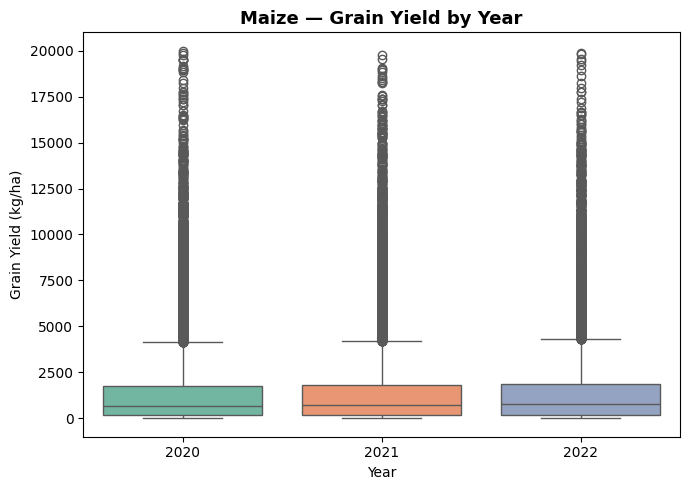

        count    mean     std  min    25%    50%     75%      max
YEAR                                                             
2020  24174.0  1402.4  2039.6  0.0  183.8  680.2  1766.0  19994.4
2021  24174.0  1429.3  2038.4  1.5  199.8  744.7  1802.5  19744.8
2022  24174.0  1443.0  1993.8  2.0  207.9  787.1  1849.1  19890.0


In [18]:
print("\n--- 1.4 Grain Yield by Year ---")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=maize, x='YEAR', y='grain_yield', palette='Set2', ax=ax)
ax.set_title('Maize — Grain Yield by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

print(maize.groupby('YEAR')['grain_yield'].describe().round(1))


--- 1.5 Region x Management Condition Interaction ---
                                          sum_sq       df           F  PR(>F)
C(region)                           4.698859e+10     16.0   2362.6582     0.0
C(environment_condition)            9.730033e+10      2.0  39139.2778     0.0
C(region):C(environment_condition)  6.274540e+10     32.0   1577.4674     0.0
Residual                            9.008153e+10  72471.0         NaN     NaN

Effect sizes (eta-squared):
  C(region)                                    : eta² = 0.1581
  C(environment_condition)                     : eta² = 0.3275
  C(region):C(environment_condition)           : eta² = 0.2112


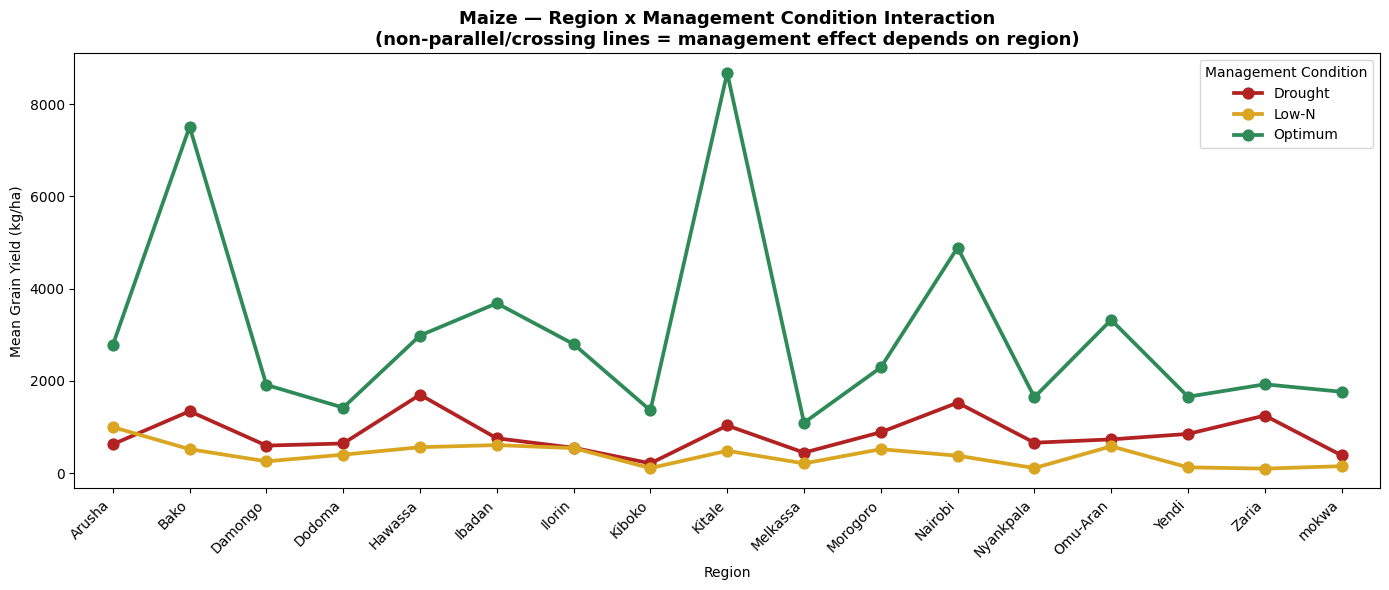

In [19]:
print("\n--- 1.5 Region x Management Condition Interaction ---")

formula = 'grain_yield ~ C(region) + C(environment_condition) + C(region):C(environment_condition)'
model_int = ols(formula, data=maize).fit()
anova_int = sm.stats.anova_lm(model_int, typ=2)
print(anova_int.round(4))

ss_total_int = anova_int['sum_sq'].sum()
print("\nEffect sizes (eta-squared):")
for term in anova_int.index[:-1]:
    print(f"  {term:<45}: eta² = {anova_int.loc[term, 'sum_sq']/ss_total_int:.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
interaction_means = maize.groupby(['region', 'environment_condition'])['grain_yield'].mean().reset_index()
sns.pointplot(data=interaction_means, x='region', y='grain_yield', hue='environment_condition',
              palette=mgmt_palette, ax=ax, markers='o', linestyles='-')
ax.set_title('Maize — Region x Management Condition Interaction\n'
             '(non-parallel/crossing lines = management effect depends on region)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Mean Grain Yield (kg/ha)')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Management Condition')
plt.tight_layout()
plt.show()

In [20]:
print("\n--- 1.6 Maize Genotype Clustering (Ward linkage) ---")

# Build genotype x (region_management) yield matrix
# This captures each genotype's general yield performance across
# all three management conditions AND across all locations.
maize['region_mgmt'] = maize['region'] + '_' + maize['environment_condition']
geno_matrix = maize.groupby(['Name', 'region_mgmt'])['grain_yield'].mean().unstack()
print(f"Genotype x Region-Management matrix shape: {geno_matrix.shape}")

# Standardise each environment column
scaler = StandardScaler()
geno_scaled = scaler.fit_transform(geno_matrix)
geno_scaled_df = pd.DataFrame(geno_scaled, index=geno_matrix.index, columns=geno_matrix.columns)

# Ward linkage — tends to produce more compact, balanced clusters
# than average linkage, since it minimises within-cluster variance
Z_ward = linkage(geno_scaled, method='ward', metric='euclidean')


--- 1.6 Maize Genotype Clustering (Ward linkage) ---
Genotype x Region-Management matrix shape: (237, 51)


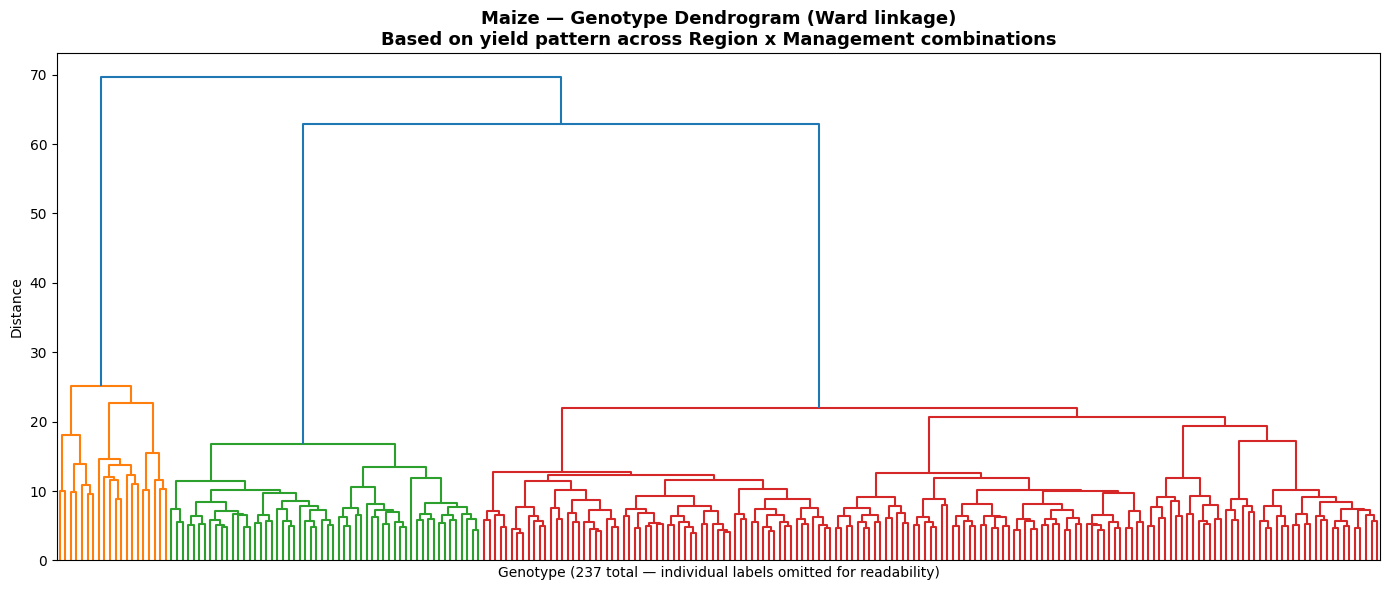

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_ward, no_labels=True, ax=ax,
           color_threshold=0.7 * max(Z_ward[:, 2]))
ax.set_title('Maize — Genotype Dendrogram (Ward linkage)\n'
             'Based on yield pattern across Region x Management combinations',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Genotype (237 total — individual labels omitted for readability)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [22]:
#    reasonably balanced split (Ward + maxclust is usually stable) ─
print("\nCluster size distribution at different k (number of clusters):")
for k in [2, 3, 4, 5, 6, 8]:
    labels_try = fcluster(Z_ward, t=k, criterion='maxclust')
    sizes = pd.Series(labels_try).value_counts().sort_values(ascending=False)
    print(f"  k={k}: sizes = {sizes.tolist()}")


Cluster size distribution at different k (number of clusters):
  k=2: sizes = [217, 20]
  k=3: sizes = [161, 56, 20]
  k=4: sizes = [161, 56, 13, 7]
  k=5: sizes = [161, 56, 8, 7, 5]
  k=6: sizes = [98, 63, 56, 8, 7, 5]
  k=8: sizes = [63, 56, 56, 28, 14, 8, 7, 5]


In [23]:
k_final = 3   # <-- adjust after reviewing the size distribution above
cluster_labels = fcluster(Z_ward, t=k_final, criterion='maxclust')
geno_matrix['Cluster'] = cluster_labels

print(f"\nFinal clustering: k={k_final}")
print(geno_matrix['Cluster'].value_counts().sort_index())


Final clustering: k=3
Cluster
1     20
2     56
3    161
Name: count, dtype: int64


In [24]:
maize_with_cluster = maize.merge(
    geno_matrix['Cluster'].reset_index(), on='Name', how='left'
)
cluster_profile = maize_with_cluster.groupby(['Cluster', 'environment_condition'])['grain_yield'].mean().unstack()
cluster_profile = cluster_profile[mgmt_order]
cluster_profile['n_genotypes'] = geno_matrix['Cluster'].value_counts()
print("\nCluster profile (mean yield by management condition):")
print(cluster_profile.round(1))


Cluster profile (mean yield by management condition):
environment_condition  Optimum  Drought  Low-N  n_genotypes
Cluster                                                    
1                       3084.7   1527.0  715.9           20
2                       4128.8    771.3  364.0           56
3                       2659.9    774.8  364.9          161


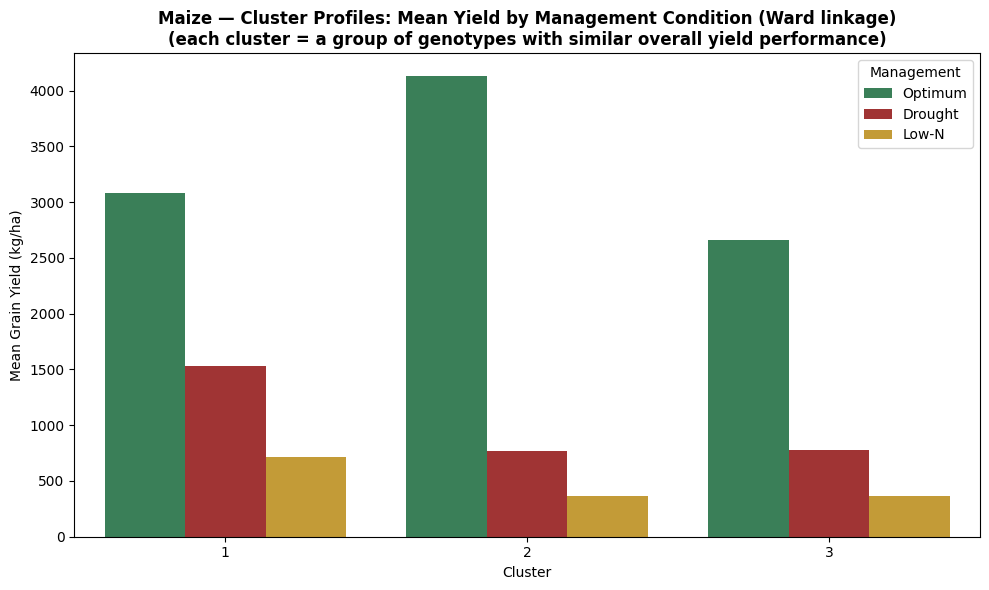

In [25]:
profile_plot = cluster_profile[mgmt_order].reset_index().melt(
    id_vars='Cluster', var_name='Management', value_name='Mean_yield'
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=profile_plot, x='Cluster', y='Mean_yield', hue='Management',
            palette=mgmt_palette, ax=ax)
ax.set_title('Maize — Cluster Profiles: Mean Yield by Management Condition (Ward linkage)\n'
             '(each cluster = a group of genotypes with similar overall yield performance)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

In [26]:
geno_matrix['Overall_mean'] = geno_matrix.drop(columns='Cluster').mean(axis=1)
print("\nTop 5 genotypes per cluster (by overall mean yield):")
for c in sorted(geno_matrix['Cluster'].unique()):
    top5 = geno_matrix[geno_matrix['Cluster'] == c].sort_values('Overall_mean', ascending=False).head(5)
    print(f"\nCluster {c}:")
    print(top5[['Overall_mean']].round(1))


Top 5 genotypes per cluster (by overall mean yield):

Cluster 1:
region_mgmt  Overall_mean
Name                     
SAMMAZ-52          2219.7
ILOMAZ-77          2203.1
ILOMAZ-61          2175.3
SAMMAZ-51          2168.4
ILOMAZ-83          2138.1

Cluster 2:
region_mgmt  Overall_mean
Name                     
ILOMAZ-79          1967.6
ILOMAZ-63          1916.7
SAMMAZ-53          1904.4
SAMMAZ-44          1882.3
TELA-23            1847.7

Cluster 3:
region_mgmt  Overall_mean
Name                     
SAMMAZ-78          1687.8
ILOMAZ-93          1683.5
TELA-13            1607.3
SAMMAZ-35          1588.4
SAMMAZ-05          1575.8


In [27]:
print("\n" + "="*60)
print("Full Genotype Listing by Cluster")
print("="*60)
for c in sorted(geno_matrix['Cluster'].unique()):
    members = geno_matrix[geno_matrix['Cluster'] == c].sort_values('Overall_mean', ascending=False)
    print(f"\nCluster {c} (n={len(members)}):")
    print(", ".join(members.index.tolist()))

# Save the full listing as a tidy table (Name, Cluster, Overall_mean)
# — useful for exporting to the report annex or the dashboard
maize_cluster_listing = geno_matrix[['Cluster', 'Overall_mean']].reset_index()
maize_cluster_listing = maize_cluster_listing.sort_values(['Cluster', 'Overall_mean'], ascending=[True, False])
print("\nFull cluster listing saved to `maize_cluster_listing` dataframe "
      f"({len(maize_cluster_listing)} genotypes).")

# Save for later use in dashboard / cross-crop comparison
maize_geno_clusters = geno_matrix[['Cluster']].copy()
maize_geno_clusters['Crop'] = 'Maize'

print("\nSection 1 (Maize) complete.")


Full Genotype Listing by Cluster

Cluster 1 (n=20):
SAMMAZ-52, ILOMAZ-77, ILOMAZ-61, SAMMAZ-51, ILOMAZ-83, ILOMAZ-84, ILOMAZ-62, ILOMAZ-76, TELA-33, SAMMAZ-57, SAMMAZ-56, TELA-15, ILOMAZ-54, TELA-14, ILOMAZ-49, SAMMAZ-28, SAMMAZ-58, ILOMAZ-55, ILOMAZ-50, TELA-16

Cluster 2 (n=56):
ILOMAZ-79, ILOMAZ-63, SAMMAZ-53, SAMMAZ-44, TELA-23, SAMMAZ-34, SAMMAZ-77, SAMMAZ-47, TELA-53, TELA-12, SAMMAZ-46, ILOMAZ-86, SAMMAZ-48, TELA-46, TELA-48, TELA-30, SAMMAZ-42, SAMMAZ-54, TELA-57, TELA-54, ILOMAZ-85, ILOMAZ-70, SAMMAZ-68, SAMMAZ-04, ILOMAZ-71, TELA-22, SAMMAZ-49, TELA-47, TELA-39, ILOMAZ-69, ILOMAZ-96, SAMMAZ-69, TELA-10, TELA-38, SAMMAZ-43, TELA-24, TELA-32, ILOMAZ-16, ILOMAZ-95, TELA-11, ILOMAZ-78, ILOMAZ-94, ILOMAZ-14, ILOMAZ-32, TELA-55, TELA-31, SAMMAZ-75, SAMMAZ-76, ILOMAZ-15, TELA-49, TELA-56, ILOMAZ-13, TELA-37, TELA-21, TELA-36, TELA-29

Cluster 3 (n=161):
SAMMAZ-78, ILOMAZ-93, TELA-13, SAMMAZ-35, SAMMAZ-05, SAMMAZ-41, ILOMAZ-64, ILOMAZ-68, ILOMAZ-72, TELA-09, TELA-25, SAMMAZ-45, SAMM

## Section 3 — Exploratory Data Analysis: Sorghum

> **AI prompt used:** *"Repeat the same stress-response EDA and genotype clustering pipeline used for Maize, applied to the Sorghum subset: yield by management condition (overall and per country) with ANOVA/Tukey HSD, yield by region and year, a Region × Management two-way ANOVA, and Ward-linkage clustering of all 60 genotypes using k=3 for consistency with the Maize analysis."

### 3.0 Sorghum — Subset Setup

Filter the Sorghum subset from the merged dataset.

In [28]:
# ============================================================
#  SORGHUM
# ============================================================
print("\n" + "="*60)
print("SECTION 2 — SORGHUM")
print("="*60)

sorghum = df[df['Crop'] == 'Sorghum'].copy()
print(f"Sorghum: {sorghum.shape[0]} rows, {sorghum['Name'].nunique()} genotypes, "
      f"{sorghum['region'].nunique()} regions, {sorghum['Country'].nunique()} countries")


SECTION 2 — SORGHUM
Sorghum: 11880 rows, 60 genotypes, 11 regions, 4 countries



--- 2.1 Yield by Management Condition (all countries combined) ---
                        count    mean     std    min     25%     50%     75%  \
environment_condition                                                          
Drought                3960.0  4105.2  2216.0  349.6  2496.2  3543.6  5282.0   
Low-N                  3960.0   922.1   536.5   90.6   503.7   865.8  1243.3   
Optimum                3960.0  5047.6  2658.4  555.0  3101.0  4520.8  6428.6   

                           max  
environment_condition           
Drought                14566.9  
Low-N                   3973.4  
Optimum                15740.3  

% loss Drought vs Optimum: 18.7%
% loss Low-N vs Optimum:   81.7%


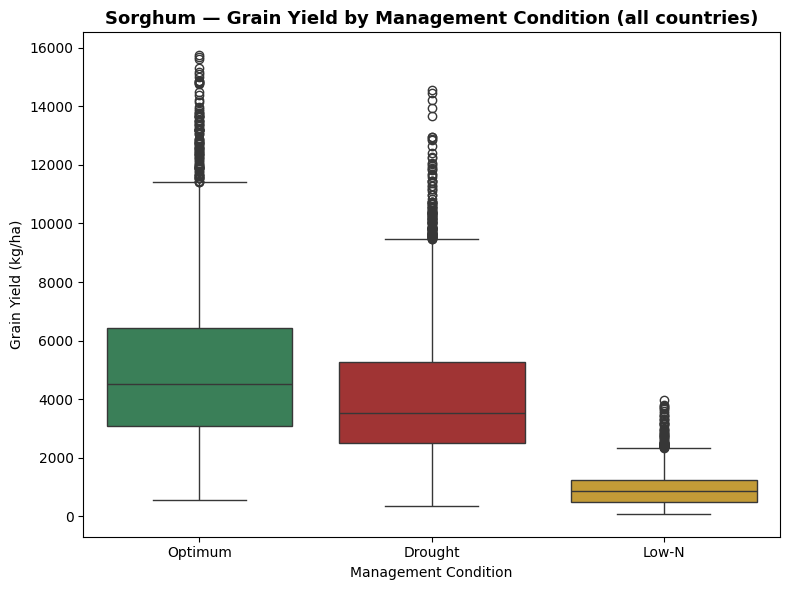

                                sum_sq       df            F  PR(>F)
C(environment_condition)  3.701271e+10      2.0  4526.332371     0.0
Residual                  4.856028e+10  11877.0          NaN     NaN
Effect size (eta-squared) = 0.4325

Tukey HSD:
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1  group2  meandiff  p-adj   lower      upper    reject
-------------------------------------------------------------
Drought   Low-N -3183.0923   0.0 -3289.6074 -3076.5772   True
Drought Optimum   942.4047   0.0   835.8895  1048.9198   True
  Low-N Optimum   4125.497   0.0  4018.9819  4232.0121   True
-------------------------------------------------------------


In [29]:
print("\n--- 2.1 Yield by Management Condition (all countries combined) ---")

desc = sorghum.groupby('environment_condition')['grain_yield'].describe()
print(desc.round(1))

means = sorghum.groupby('environment_condition')['grain_yield'].mean()
print(f"\n% loss Drought vs Optimum: {(1 - means['Drought']/means['Optimum'])*100:.1f}%")
print(f"% loss Low-N vs Optimum:   {(1 - means['Low-N']/means['Optimum'])*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=sorghum, x='environment_condition', y='grain_yield',
            order=mgmt_order, palette=mgmt_palette, ax=ax)
ax.set_title('Sorghum — Grain Yield by Management Condition (all countries)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Management Condition')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

model = ols('grain_yield ~ C(environment_condition)', data=sorghum).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
eta_sq = anova_table.loc['C(environment_condition)', 'sum_sq'] / anova_table['sum_sq'].sum()
print(f"Effect size (eta-squared) = {eta_sq:.4f}")

tukey = pairwise_tukeyhsd(sorghum['grain_yield'], sorghum['environment_condition'])
print("\nTukey HSD:")
print(tukey)


--- 2.2 Yield by Management Condition — Per Country ---


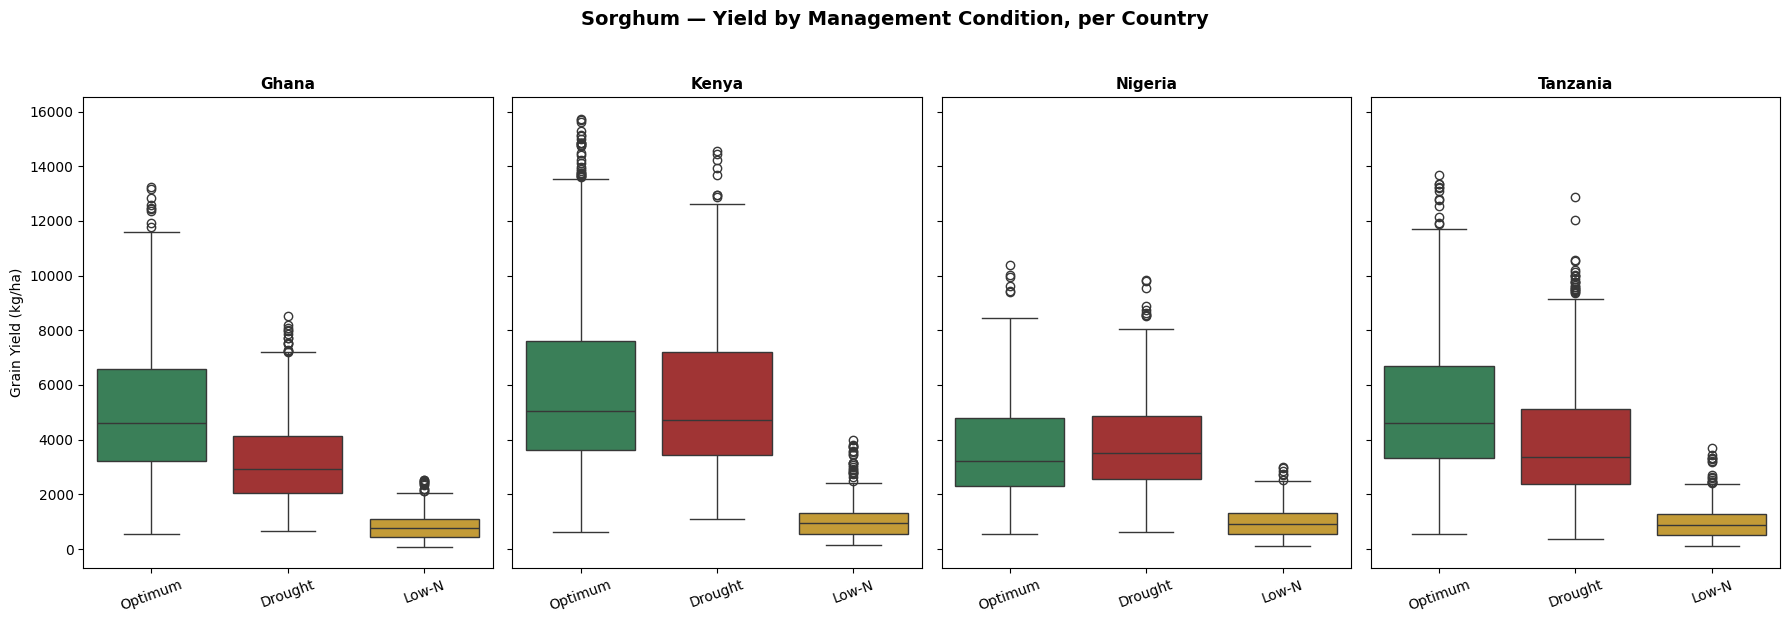


Per-country ANOVA summary:
Country          F-stat      p-value     eta²   % loss Drought   % loss Low-N
------------------------------------------------------------------------------
Ghana            1752.7     0.00e+00   0.5199            36.9%          84.7%
Kenya            1386.3     0.00e+00   0.4614             8.6%          82.8%
Nigeria           859.2    3.58e-275   0.4434            -6.2%          73.8%
Tanzania         1380.4     0.00e+00   0.4603            23.9%          81.3%


In [30]:
print("\n--- 2.2 Yield by Management Condition — Per Country ---")

countries_sorghum = sorted(sorghum['Country'].unique())
fig, axes = plt.subplots(1, len(countries_sorghum), figsize=(18, 6), sharey=True)
for i, country in enumerate(countries_sorghum):
    sub = sorghum[sorghum['Country'] == country]
    sns.boxplot(data=sub, x='environment_condition', y='grain_yield',
                order=mgmt_order, palette=mgmt_palette, ax=axes[i])
    axes[i].set_title(country, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Grain Yield (kg/ha)' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=20)
plt.suptitle('Sorghum — Yield by Management Condition, per Country', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nPer-country ANOVA summary:")
print(f"{'Country':<12} {'F-stat':>10} {'p-value':>12} {'eta²':>8} "
      f"{'% loss Drought':>16} {'% loss Low-N':>14}")
print("-" * 78)
for country in countries_sorghum:
    sub = sorghum[sorghum['Country'] == country]
    m = ols('grain_yield ~ C(environment_condition)', data=sub).fit()
    at = sm.stats.anova_lm(m, typ=2)
    f_stat = at.loc['C(environment_condition)', 'F']
    p_val  = at.loc['C(environment_condition)', 'PR(>F)']
    eta    = at.loc['C(environment_condition)', 'sum_sq'] / at['sum_sq'].sum()
    cm = sub.groupby('environment_condition')['grain_yield'].mean()
    loss_drought = (1 - cm['Drought'] / cm['Optimum']) * 100
    loss_lown    = (1 - cm['Low-N']   / cm['Optimum']) * 100
    print(f"{country:<12} {f_stat:>10.1f} {p_val:>12.2e} {eta:>8.4f} "
          f"{loss_drought:>15.1f}% {loss_lown:>13.1f}%")


--- 2.3 Grain Yield by Region ---


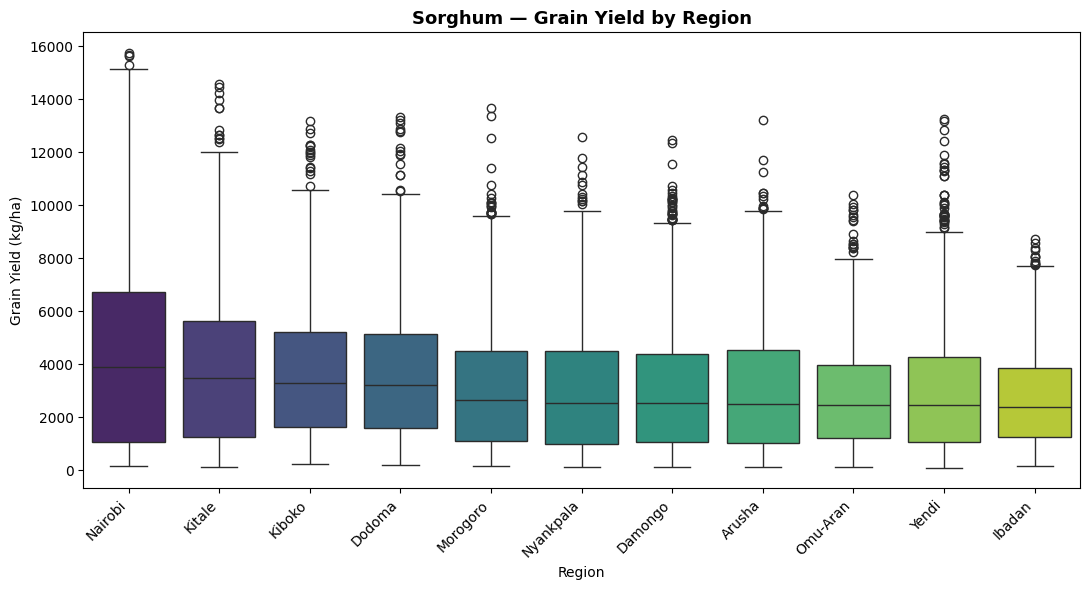

In [31]:
print("\n--- 2.3 Grain Yield by Region ---")

fig, ax = plt.subplots(figsize=(11, 6))
order_region = sorghum.groupby('region')['grain_yield'].median().sort_values(ascending=False).index
sns.boxplot(data=sorghum, x='region', y='grain_yield', order=order_region,
            palette='viridis', ax=ax)
ax.set_title('Sorghum — Grain Yield by Region', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- 2.4 Grain Yield by Year ---


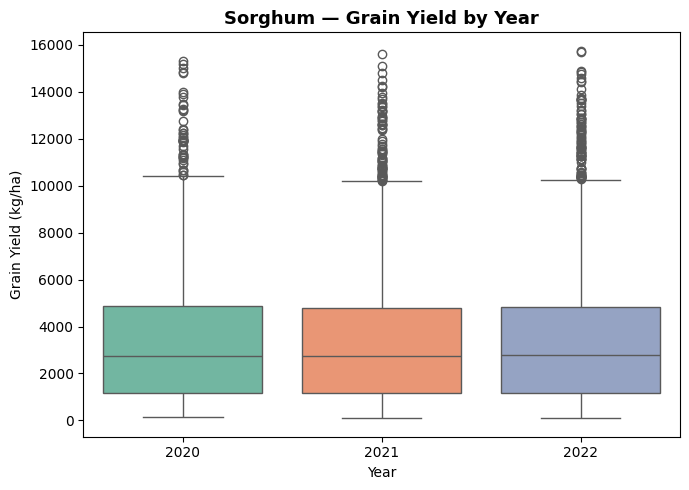

       count    mean     std    min     25%     50%     75%      max
YEAR                                                                
2020  3960.0  3343.0  2643.1  127.5  1149.8  2758.2  4862.0  15297.5
2021  3960.0  3352.8  2666.7   90.6  1190.5  2762.0  4800.3  15615.2
2022  3960.0  3379.0  2741.7  101.9  1179.0  2769.6  4817.1  15740.3


In [32]:
print("\n--- 2.4 Grain Yield by Year ---")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=sorghum, x='YEAR', y='grain_yield', palette='Set2', ax=ax)
ax.set_title('Sorghum — Grain Yield by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

print(sorghum.groupby('YEAR')['grain_yield'].describe().round(1))


--- 2.5 Region x Management Condition Interaction ---
                                          sum_sq       df          F  PR(>F)
C(region)                           3.294595e+09     10.0    94.1438     0.0
C(environment_condition)            3.701271e+10      2.0  5288.2296     0.0
C(region):C(environment_condition)  3.806672e+09     20.0    54.3882     0.0
Residual                            4.145901e+10  11847.0        NaN     NaN

Effect sizes (eta-squared):
  C(region)                                    : eta² = 0.0385
  C(environment_condition)                     : eta² = 0.4325
  C(region):C(environment_condition)           : eta² = 0.0445


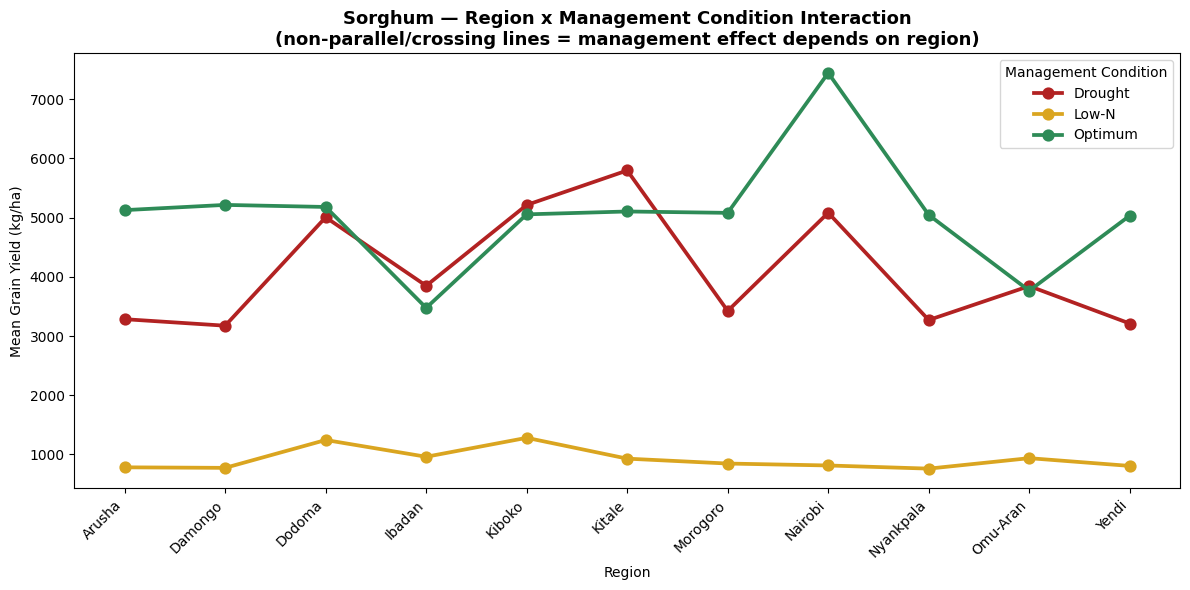

In [33]:
print("\n--- 2.5 Region x Management Condition Interaction ---")

formula = 'grain_yield ~ C(region) + C(environment_condition) + C(region):C(environment_condition)'
model_int = ols(formula, data=sorghum).fit()
anova_int = sm.stats.anova_lm(model_int, typ=2)
print(anova_int.round(4))

ss_total_int = anova_int['sum_sq'].sum()
print("\nEffect sizes (eta-squared):")
for term in anova_int.index[:-1]:
    print(f"  {term:<45}: eta² = {anova_int.loc[term, 'sum_sq']/ss_total_int:.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
interaction_means = sorghum.groupby(['region', 'environment_condition'])['grain_yield'].mean().reset_index()
sns.pointplot(data=interaction_means, x='region', y='grain_yield', hue='environment_condition',
              palette=mgmt_palette, ax=ax, markers='o', linestyles='-')
ax.set_title('Sorghum — Region x Management Condition Interaction\n'
             '(non-parallel/crossing lines = management effect depends on region)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Mean Grain Yield (kg/ha)')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Management Condition')
plt.tight_layout()
plt.show()


--- 2.6 Sorghum Genotype Clustering (Ward linkage) ---
Genotype x Region-Management matrix shape: (60, 33)


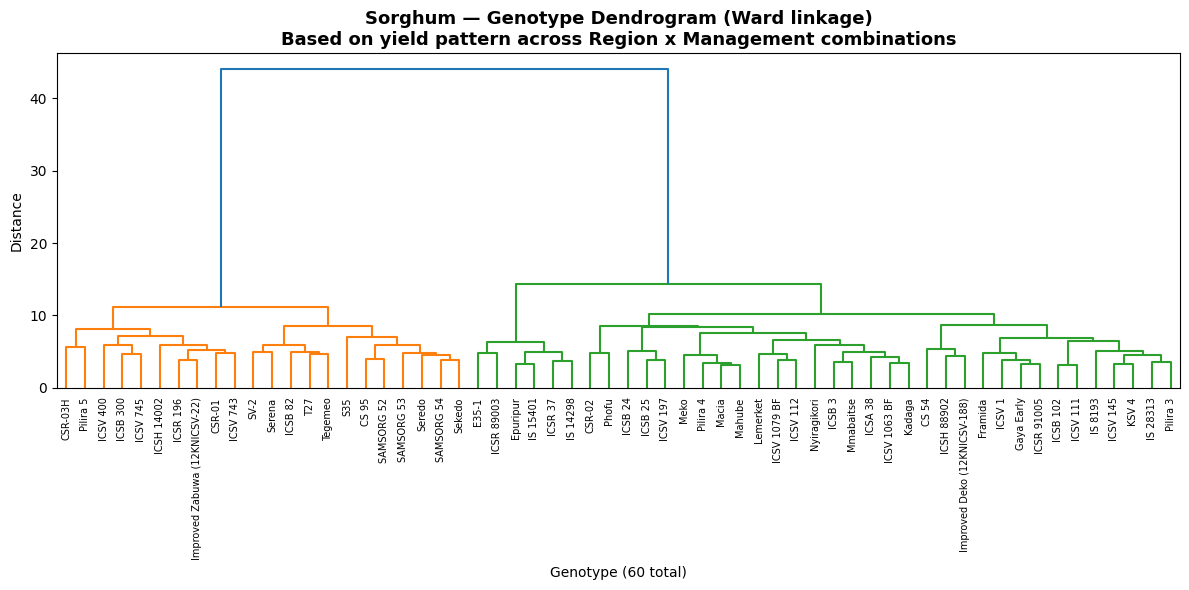


Cluster size distribution at different k (number of clusters):
  k=2: sizes = [38, 22]
  k=3: sizes = [32, 22, 6]
  k=4: sizes = [32, 12, 10, 6]
  k=5: sizes = [18, 14, 12, 10, 6]
  k=6: sizes = [18, 12, 11, 10, 6, 3]

Final clustering: k=3
Cluster
1    22
2     6
3    32
Name: count, dtype: int64

Cluster profile (mean yield by management condition):
environment_condition  Optimum  Drought  Low-N  n_genotypes
Cluster                                                    
1                       7169.2   5863.2  933.4           22
2                       2385.1   2003.3  944.4            6
3                       4088.2   3290.7  910.2           32


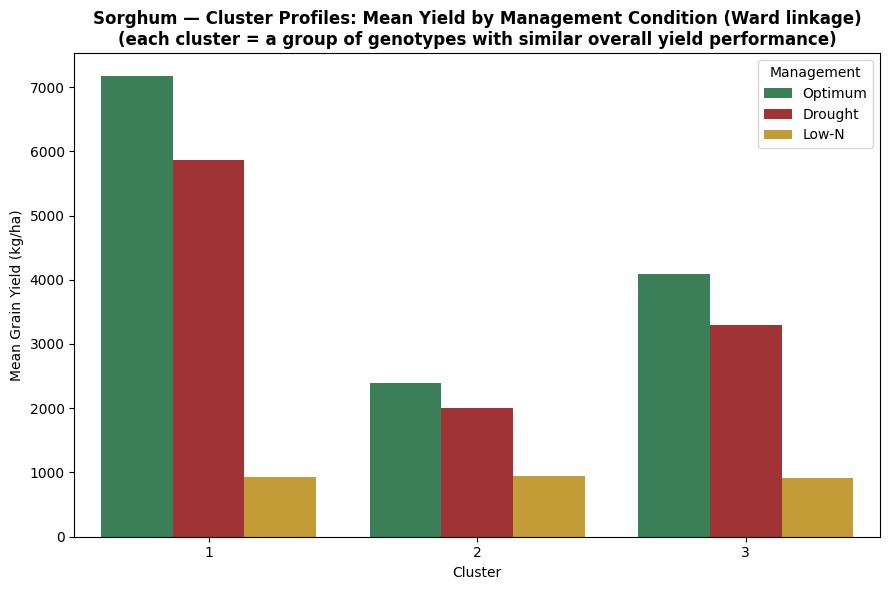


Full Genotype Listing by Cluster:

Cluster 1 (n=22):
S35, Sekedo, Serena, SAMSORG 52, CS 95, SV-2, ICSB 82, Improved Zabuwa (12KNICSV-22), Tegemeo, SAMSORG 54, CSR-03H, ICSV 743, Seredo, T27, SAMSORG 53, ICSH 14002, CSR-01, ICSR 196, ICSV 745, Pilira 5, ICSB 300, ICSV 400

Cluster 2 (n=6):
E35-1, IS 14298, ICSR 37, IS 15401, Epuripur, ICSR 89003

Cluster 3 (n=32):
CS 54, Improved Deko (12KNICSV-188), CSR-02, ICSH 88902, ICSV 1063 BF, Phofu, Kadaga, ICSV 1, ICSR 91005, Nyiragikori, IS 8193, ICSB 3, ICSV 197, Lemerket, ICSB 24, IS 28313, Pilira 3, Mmabaitse, KSV 4, ICSV 1079 BF, Meko, ICSV 112, Macia, ICSB 25, Gaya Early, ICSB 102, Framida, ICSV 145, Mahube, ICSV 111, ICSA 38, Pilira 4

Section 2 (Sorghum) complete.


In [34]:
print("\n--- 2.6 Sorghum Genotype Clustering (Ward linkage) ---")

sorghum['region_mgmt'] = sorghum['region'] + '_' + sorghum['environment_condition']
geno_matrix_s = sorghum.groupby(['Name', 'region_mgmt'])['grain_yield'].mean().unstack()
print(f"Genotype x Region-Management matrix shape: {geno_matrix_s.shape}")

scaler_s = StandardScaler()
geno_scaled_s = scaler_s.fit_transform(geno_matrix_s)

Z_ward_s = linkage(geno_scaled_s, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z_ward_s, labels=geno_matrix_s.index.tolist(), ax=ax,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z_ward_s[:, 2]))
ax.set_title('Sorghum — Genotype Dendrogram (Ward linkage)\n'
             'Based on yield pattern across Region x Management combinations',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Genotype (60 total)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

print("\nCluster size distribution at different k (number of clusters):")
for k in [2, 3, 4, 5, 6]:
    labels_try = fcluster(Z_ward_s, t=k, criterion='maxclust')
    sizes = pd.Series(labels_try).value_counts().sort_values(ascending=False)
    print(f"  k={k}: sizes = {sizes.tolist()}")

# Using k=3 to match the final choice made for Maize
k_final_s = 3
cluster_labels_s = fcluster(Z_ward_s, t=k_final_s, criterion='maxclust')
geno_matrix_s['Cluster'] = cluster_labels_s

print(f"\nFinal clustering: k={k_final_s}")
print(geno_matrix_s['Cluster'].value_counts().sort_index())

sorghum_with_cluster = sorghum.merge(
    geno_matrix_s['Cluster'].reset_index(), on='Name', how='left'
)
cluster_profile_s = sorghum_with_cluster.groupby(['Cluster', 'environment_condition'])['grain_yield'].mean().unstack()
cluster_profile_s = cluster_profile_s[mgmt_order]
cluster_profile_s['n_genotypes'] = geno_matrix_s['Cluster'].value_counts()
print("\nCluster profile (mean yield by management condition):")
print(cluster_profile_s.round(1))

profile_plot_s = cluster_profile_s[mgmt_order].reset_index().melt(
    id_vars='Cluster', var_name='Management', value_name='Mean_yield'
)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=profile_plot_s, x='Cluster', y='Mean_yield', hue='Management',
            palette=mgmt_palette, ax=ax)
ax.set_title('Sorghum — Cluster Profiles: Mean Yield by Management Condition (Ward linkage)\n'
             '(each cluster = a group of genotypes with similar overall yield performance)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

geno_matrix_s['Overall_mean'] = geno_matrix_s.drop(columns='Cluster').mean(axis=1)
print("\nFull Genotype Listing by Cluster:")
for c in sorted(geno_matrix_s['Cluster'].unique()):
    members = geno_matrix_s[geno_matrix_s['Cluster'] == c].sort_values('Overall_mean', ascending=False)
    print(f"\nCluster {c} (n={len(members)}):")
    print(", ".join(members.index.tolist()))

sorghum_cluster_listing = geno_matrix_s[['Cluster', 'Overall_mean']].reset_index()
sorghum_cluster_listing = sorghum_cluster_listing.sort_values(['Cluster', 'Overall_mean'], ascending=[True, False])

sorghum_geno_clusters = geno_matrix_s[['Cluster']].copy()
sorghum_geno_clusters['Crop'] = 'Sorghum'

print("\nSection 2 (Sorghum) complete.")

## Section 4 — Exploratory Data Analysis: Cowpea and Rice

> **AI prompt used:** *"For Cowpea and Rice, which were only evaluated under Optimum management, run a descriptive EDA (yield by country, by region, and by year, with ANOVA where more than one country is present) and a Ward-linkage genotype performance classification for each crop, relabelling cluster numbers by mean yield so Cluster 1 always represents the highest-yielding tier."

### Cowpea

### Subset Setup

Filter this crop's subset from the merged dataset.

In [35]:
# ============================================================
#  COWPEA
# ============================================================
print("\n" + "="*60)
print("SECTION 3 — COWPEA")
print("="*60)

cowpea = df[df['Crop'] == 'Cowpea'].copy()
print(f"Cowpea: {cowpea.shape[0]} rows, {cowpea['Name'].nunique()} genotypes, "
      f"{cowpea['region'].nunique()} regions, {cowpea['Country'].nunique()} countries")
print(f"Management conditions present: {cowpea['environment_condition'].unique().tolist()} "
      f"(Optimum only — no stress comparison possible)")


SECTION 3 — COWPEA
Cowpea: 2400 rows, 50 genotypes, 8 regions, 2 countries
Management conditions present: ['Optimum'] (Optimum only — no stress comparison possible)



--- 3.1 Grain Yield by Country ---
          count    mean     std   min     25%     50%     75%      max
Country                                                               
Ghana     900.0  2207.1  1547.2  15.8   941.4  1959.1  3115.4   9516.0
Nigeria  1500.0  2746.6  1861.7   0.2  1250.3  2622.2  3979.0  10910.0


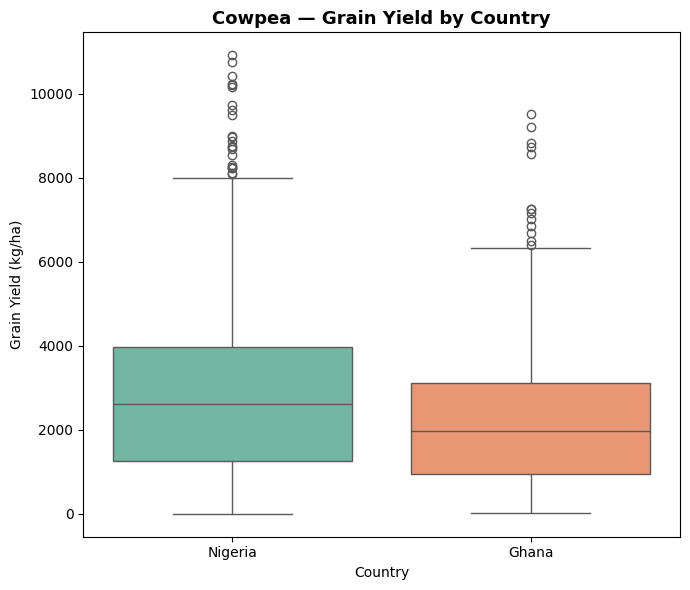

                  sum_sq      df          F        PR(>F)
C(Country)  1.637326e+08     1.0  53.437845  3.618318e-13
Residual    7.347428e+09  2398.0        NaN           NaN
Effect size (eta-squared) = 0.0218


In [36]:
print("\n--- 3.1 Grain Yield by Country ---")

print(cowpea.groupby('Country')['grain_yield'].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=cowpea, x='Country', y='grain_yield', palette='Set2', ax=ax)
ax.set_title('Cowpea — Grain Yield by Country', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

model_c = ols('grain_yield ~ C(Country)', data=cowpea).fit()
anova_c = sm.stats.anova_lm(model_c, typ=2)
print(anova_c)
eta_c = anova_c.loc['C(Country)', 'sum_sq'] / anova_c['sum_sq'].sum()
print(f"Effect size (eta-squared) = {eta_c:.4f}")


--- 3.2 Grain Yield by Region ---


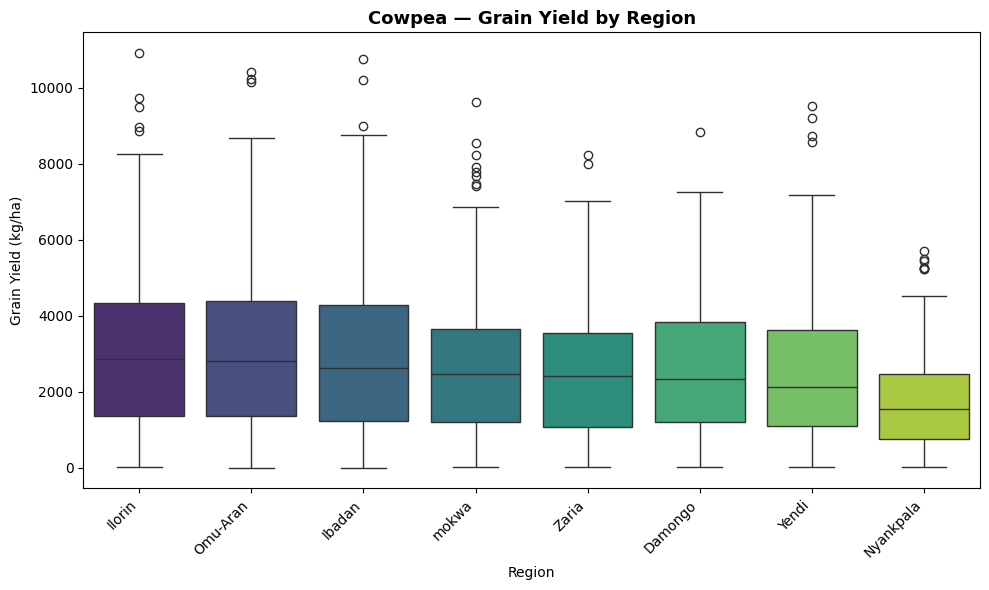

In [37]:
print("\n--- 3.2 Grain Yield by Region ---")

fig, ax = plt.subplots(figsize=(10, 6))
order_region_c = cowpea.groupby('region')['grain_yield'].median().sort_values(ascending=False).index
sns.boxplot(data=cowpea, x='region', y='grain_yield', order=order_region_c,
            palette='viridis', ax=ax)
ax.set_title('Cowpea — Grain Yield by Region', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- 3.3 Grain Yield by Year ---


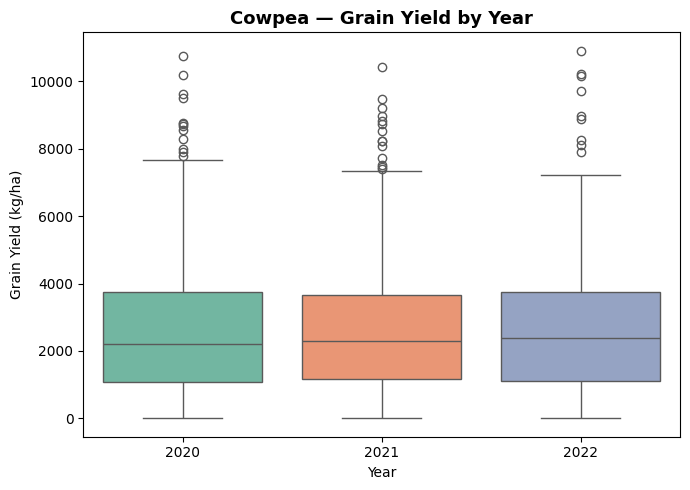

      count    mean     std   min     25%     50%     75%      max
YEAR                                                              
2020  800.0  2535.4  1808.0   0.2  1087.9  2220.3  3762.9  10750.9
2021  800.0  2541.7  1768.0   8.6  1181.7  2284.0  3669.7  10416.6
2022  800.0  2555.8  1733.7  13.1  1113.2  2394.8  3738.2  10910.0


In [38]:
print("\n--- 3.3 Grain Yield by Year ---")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=cowpea, x='YEAR', y='grain_yield', palette='Set2', ax=ax)
ax.set_title('Cowpea — Grain Yield by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

print(cowpea.groupby('YEAR')['grain_yield'].describe().round(1))


--- 3.4 Cowpea Genotype Classification ---
(No management dimension available — classification is based on overall yield level across regions only: High / Moderate / Low)
Genotype x Region matrix shape: (50, 8)


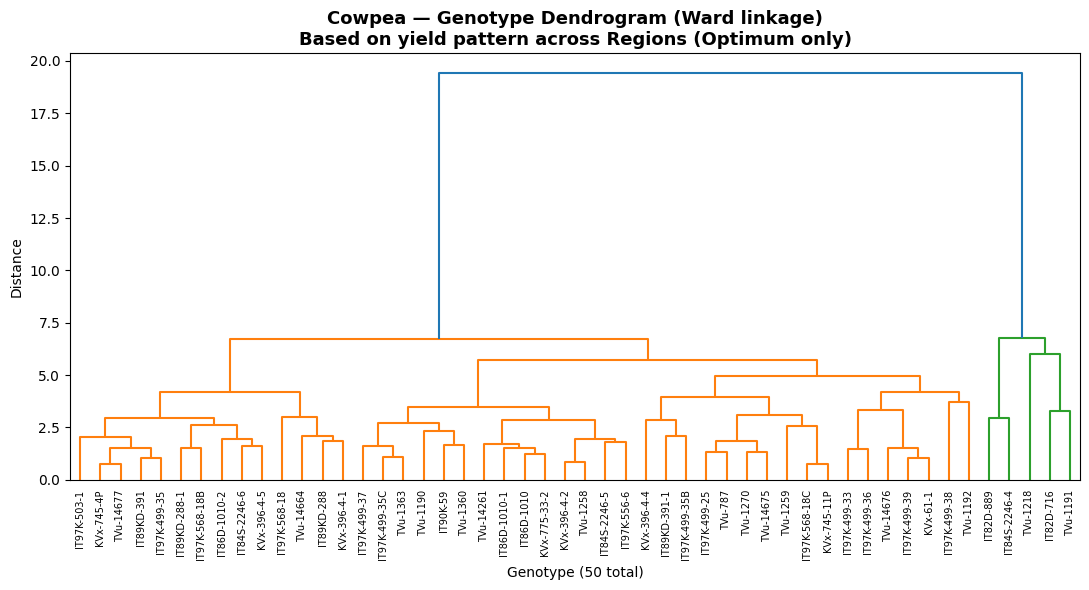


Cluster size distribution at different k:
  k=2: sizes = [45, 5]
  k=3: sizes = [45, 3, 2]
  k=4: sizes = [31, 14, 3, 2]
  k=5: sizes = [31, 14, 2, 2, 1]

Final clustering: k=2
Performance_level
Low-yielding     45
High-yielding     5
Name: count, dtype: int64

Performance level profile (mean yield):
                   count    mean    std     min     25%     50%     75%  \
Performance_level                                                         
High-yielding        5.0  4419.3  463.7  3923.1  4017.3  4403.0  4746.1   
Low-yielding        45.0  2336.0  266.2  1794.2  2133.7  2357.0  2487.4   

                      max  
Performance_level          
High-yielding      5006.8  
Low-yielding       3258.3  

Full Genotype Listing by Performance Level:

High-yielding (n=5):
TVu-1191, IT82D-716, IT84S-2246-4, TVu-1218, IT82D-889

Moderate-yielding (n=0):


Low-yielding (n=45):
TVu-1192, IT97K-499-38, KVx-745-11P, IT97K-568-18C, IT97K-499-37, IT97K-499-35C, IT97K-499-33, IT97K-499-35B, TVu

In [39]:
print("\n--- 3.4 Cowpea Genotype Classification ---")
print("(No management dimension available — classification is based "
      "on overall yield level across regions only: High / Moderate / Low)")

geno_region_c = cowpea.groupby(['Name', 'region'])['grain_yield'].mean().unstack()
print(f"Genotype x Region matrix shape: {geno_region_c.shape}")

scaler_c = StandardScaler()
geno_scaled_c = scaler_c.fit_transform(geno_region_c)

Z_ward_c = linkage(geno_scaled_c, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(11, 6))
dendrogram(Z_ward_c, labels=geno_region_c.index.tolist(), ax=ax,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z_ward_c[:, 2]))
ax.set_title('Cowpea — Genotype Dendrogram (Ward linkage)\n'
             'Based on yield pattern across Regions (Optimum only)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Genotype (50 total)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

print("\nCluster size distribution at different k:")
for k in [2, 3, 4, 5]:
    labels_try = fcluster(Z_ward_c, t=k, criterion='maxclust')
    sizes = pd.Series(labels_try).value_counts().sort_values(ascending=False)
    print(f"  k={k}: sizes = {sizes.tolist()}")

k_final_c = 2
cluster_labels_c = fcluster(Z_ward_c, t=k_final_c, criterion='maxclust')
geno_region_c['Cluster'] = cluster_labels_c
geno_region_c['Overall_mean'] = geno_region_c.drop(columns='Cluster').mean(axis=1)

# Relabel clusters by mean yield rank so "1" is always High, etc.
cluster_rank_c = geno_region_c.groupby('Cluster')['Overall_mean'].mean().sort_values(ascending=False)
rank_map_c = {old: label for old, label in zip(cluster_rank_c.index, ['High-yielding', 'Low-yielding'])}
geno_region_c['Performance_level'] = geno_region_c['Cluster'].map(rank_map_c)

print(f"\nFinal clustering: k={k_final_c}")
print(geno_region_c['Performance_level'].value_counts())

print("\nPerformance level profile (mean yield):")
print(geno_region_c.groupby('Performance_level')['Overall_mean'].describe().round(1))

print("\nFull Genotype Listing by Performance Level:")
for level in ['High-yielding', 'Moderate-yielding', 'Low-yielding']:
    members = geno_region_c[geno_region_c['Performance_level'] == level].sort_values('Overall_mean', ascending=False)
    print(f"\n{level} (n={len(members)}):")
    print(", ".join(members.index.tolist()))

cowpea_geno_levels = geno_region_c[['Performance_level', 'Overall_mean']].copy()
cowpea_geno_levels['Crop'] = 'Cowpea'

print("\nSection 3 (Cowpea) complete.")

### Rice

### Subset Setup

Filter this crop's subset from the merged dataset.

In [40]:
# ============================================================
#  SECTION 4 — RICE
# ============================================================
print("\n" + "="*60)
print("SECTION 4 — RICE")
print("="*60)

rice = df[df['Crop'] == 'Rice'].copy()
print(f"Rice: {rice.shape[0]} rows, {rice['Name'].nunique()} genotypes, "
      f"{rice['region'].nunique()} regions, {rice['Country'].nunique()} countries")
print(f"Management conditions present: {rice['environment_condition'].unique().tolist()} "
      f"(Optimum only — no stress comparison possible)")


SECTION 4 — RICE
Rice: 3960 rows, 60 genotypes, 11 regions, 3 countries
Management conditions present: ['Optimum'] (Optimum only — no stress comparison possible)



--- 4.1 Grain Yield by Country ---
          count    mean     std   min     25%     50%     75%      max
Country                                                               
Ghana    1080.0  3176.8  2051.8  15.6  1502.5  2984.3  4657.3   8745.3
Kenya    1080.0  5096.2  3435.5  12.0  2239.8  4610.4  7412.3  15617.7
Nigeria  1800.0  3386.8  2220.4  18.3  1589.3  3149.2  4886.7  10329.7


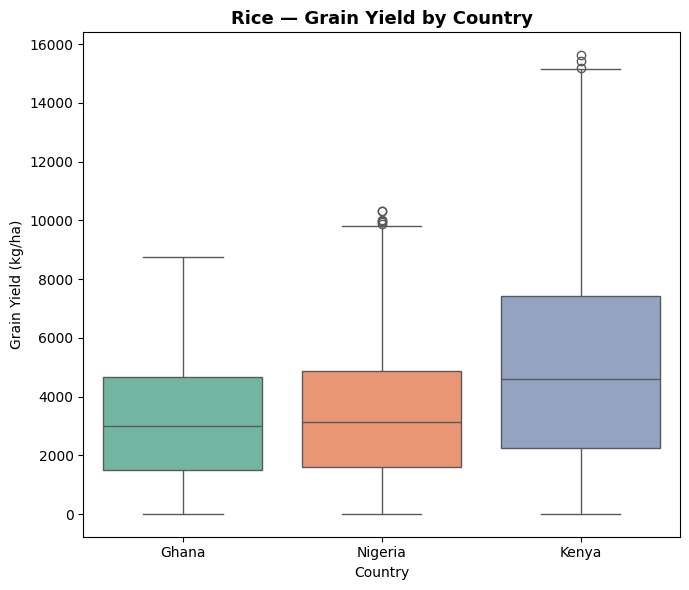

                  sum_sq      df           F        PR(>F)
C(Country)  2.541312e+09     2.0  192.292377  2.002635e-80
Residual    2.614760e+10  3957.0         NaN           NaN
Effect size (eta-squared) = 0.0886


In [41]:
print("\n--- 4.1 Grain Yield by Country ---")

print(rice.groupby('Country')['grain_yield'].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=rice, x='Country', y='grain_yield', palette='Set2', ax=ax)
ax.set_title('Rice — Grain Yield by Country', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

model_r = ols('grain_yield ~ C(Country)', data=rice).fit()
anova_r = sm.stats.anova_lm(model_r, typ=2)
print(anova_r)
eta_r = anova_r.loc['C(Country)', 'sum_sq'] / anova_r['sum_sq'].sum()
print(f"Effect size (eta-squared) = {eta_r:.4f}")


--- 4.2 Grain Yield by Region ---


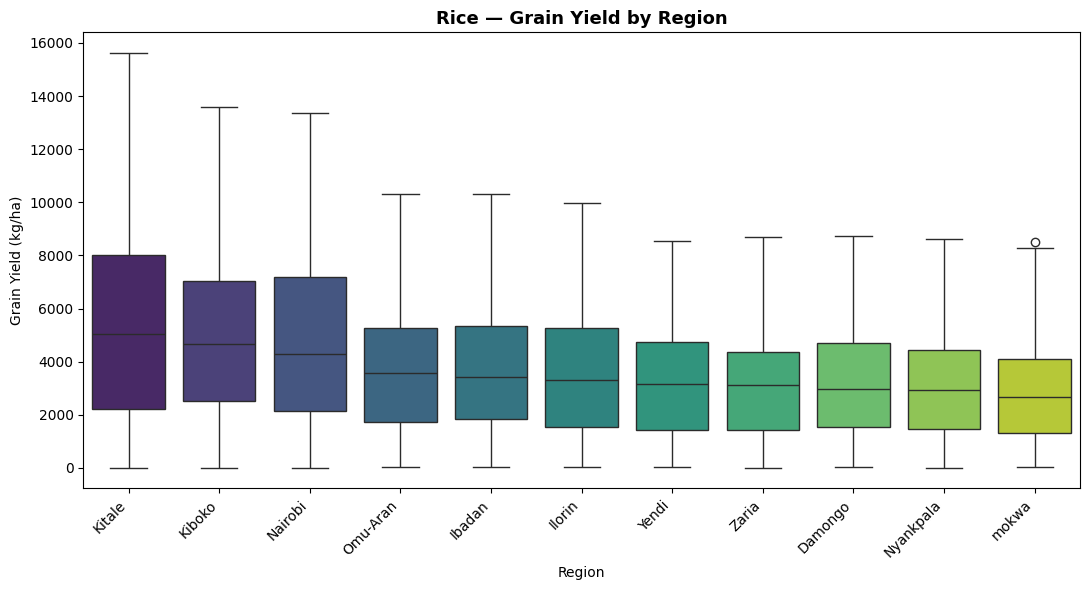

In [42]:
print("\n--- 4.2 Grain Yield by Region ---")

fig, ax = plt.subplots(figsize=(11, 6))
order_region_r = rice.groupby('region')['grain_yield'].median().sort_values(ascending=False).index
sns.boxplot(data=rice, x='region', y='grain_yield', order=order_region_r,
            palette='viridis', ax=ax)
ax.set_title('Rice — Grain Yield by Region', fontsize=13, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- 4.3 Grain Yield by Year ---


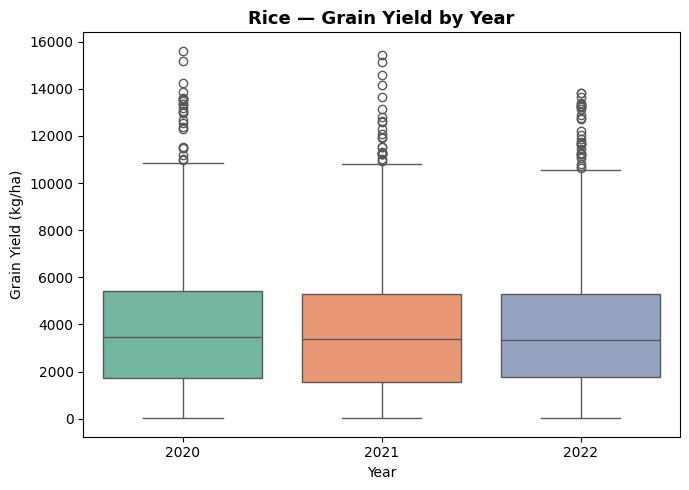

       count    mean     std   min     25%     50%     75%      max
YEAR                                                               
2020  1320.0  3835.7  2699.1  12.0  1738.5  3450.6  5400.7  15617.7
2021  1320.0  3745.0  2665.0  15.1  1564.4  3372.3  5277.1  15438.7
2022  1320.0  3806.5  2712.7  18.3  1748.7  3353.4  5295.0  13827.0


In [43]:
print("\n--- 4.3 Grain Yield by Year ---")

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=rice, x='YEAR', y='grain_yield', palette='Set2', ax=ax)
ax.set_title('Rice — Grain Yield by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Grain Yield (kg/ha)')
plt.tight_layout()
plt.show()

print(rice.groupby('YEAR')['grain_yield'].describe().round(1))


--- 4.4 Rice Genotype Classification ---
(No management dimension available — classification is based on overall yield level across regions only: High / Moderate / Low)
Genotype x Region matrix shape: (60, 11)


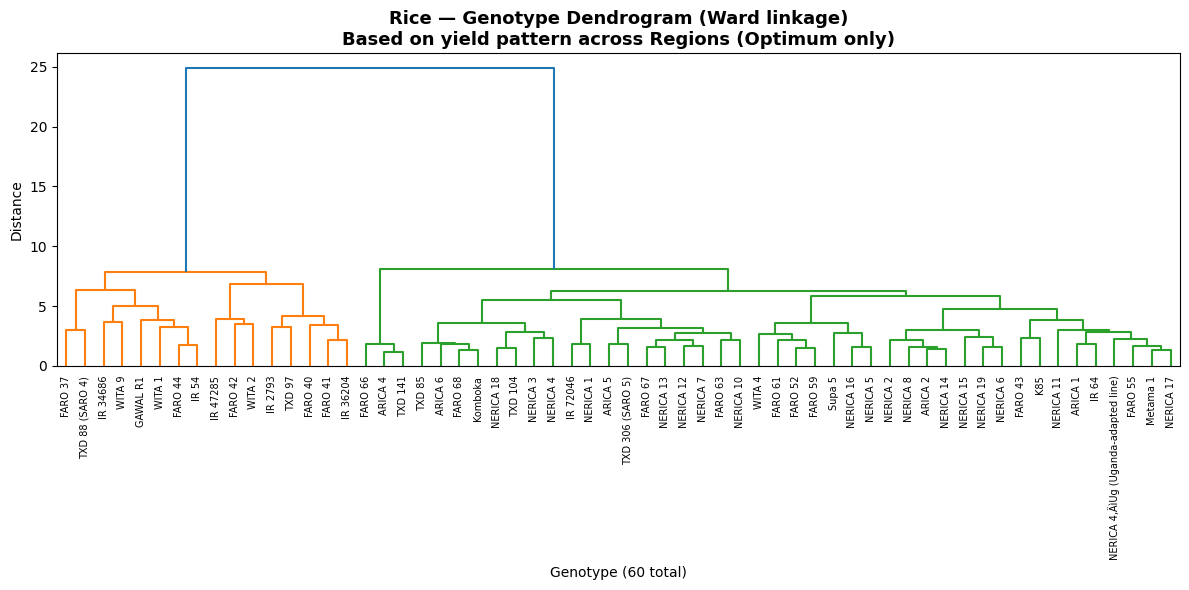


Cluster size distribution at different k:
  k=2: sizes = [44, 16]
  k=3: sizes = [41, 16, 3]
  k=4: sizes = [41, 8, 8, 3]
  k=5: sizes = [41, 8, 5, 3, 3]

Final clustering: k=2
Performance_level
Low-yielding     44
High-yielding    16
Name: count, dtype: int64

Performance level profile (mean yield):
                   count    mean    std     min     25%     50%     75%  \
Performance_level                                                         
High-yielding       16.0  5421.1  612.6  4378.8  5048.0  5356.4  5907.1   
Low-yielding        44.0  3204.7  490.2  1765.1  3019.3  3317.7  3506.9   

                      max  
Performance_level          
High-yielding      6474.4  
Low-yielding       3982.2  

Full Genotype Listing by Performance Level:

High-yielding (n=16):
IR 2793, FARO 40, TXD 97, FARO 41, IR 36204, IR 34686, WITA 9, WITA 2, FARO 42, TXD 88 (SARO 4), FARO 44, IR 54, WITA 1, GAWAL R1, FARO 37, IR 47285

Moderate-yielding (n=0):


Low-yielding (n=44):
WITA 4, FARO 61, A

In [44]:
print("\n--- 4.4 Rice Genotype Classification ---")
print("(No management dimension available — classification is based "
      "on overall yield level across regions only: High / Moderate / Low)")

geno_region_r = rice.groupby(['Name', 'region'])['grain_yield'].mean().unstack()
print(f"Genotype x Region matrix shape: {geno_region_r.shape}")

scaler_r = StandardScaler()
geno_scaled_r = scaler_r.fit_transform(geno_region_r)

Z_ward_r = linkage(geno_scaled_r, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z_ward_r, labels=geno_region_r.index.tolist(), ax=ax,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z_ward_r[:, 2]))
ax.set_title('Rice — Genotype Dendrogram (Ward linkage)\n'
             'Based on yield pattern across Regions (Optimum only)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Genotype (60 total)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

print("\nCluster size distribution at different k:")
for k in [2, 3, 4, 5]:
    labels_try = fcluster(Z_ward_r, t=k, criterion='maxclust')
    sizes = pd.Series(labels_try).value_counts().sort_values(ascending=False)
    print(f"  k={k}: sizes = {sizes.tolist()}")

k_final_r = 2
cluster_labels_r = fcluster(Z_ward_r, t=k_final_r, criterion='maxclust')
geno_region_r['Cluster'] = cluster_labels_r
geno_region_r['Overall_mean'] = geno_region_r.drop(columns='Cluster').mean(axis=1)

cluster_rank_r = geno_region_r.groupby('Cluster')['Overall_mean'].mean().sort_values(ascending=False)
rank_map_r = {old: label for old, label in zip(cluster_rank_r.index, ['High-yielding', 'Low-yielding'])}
geno_region_r['Performance_level'] = geno_region_r['Cluster'].map(rank_map_r)

print(f"\nFinal clustering: k={k_final_r}")
print(geno_region_r['Performance_level'].value_counts())

print("\nPerformance level profile (mean yield):")
print(geno_region_r.groupby('Performance_level')['Overall_mean'].describe().round(1))

print("\nFull Genotype Listing by Performance Level:")
for level in ['High-yielding', 'Moderate-yielding', 'Low-yielding']:
    members = geno_region_r[geno_region_r['Performance_level'] == level].sort_values('Overall_mean', ascending=False)
    print(f"\n{level} (n={len(members)}):")
    print(", ".join(members.index.tolist()))

rice_geno_levels = geno_region_r[['Performance_level', 'Overall_mean']].copy()
rice_geno_levels['Crop'] = 'Rice'

print("\nSection 4 (Rice) complete.")

## Section 5 — Cross-Crop Comparison: Environmental Drivers and Genotype-by-Environment Analysis

This section addresses Hypothesis 2 directly: which environmental and soil factors drive yield across all four crops, and how do genotypes interact with their growing environment?

> **AI prompt used:** *"Reload the full merged dataset fresh for this section. Then run a cross-crop comparison covering: (A) exploratory analysis — scatter plots of yield against each environmental/soil variable faceted by crop, a correlation heatmap per crop, and a PCA of the six environmental/soil variables coloured by crop; (B) inferential statistics — a multiple linear regression of yield on the six environmental/soil variables for each crop with R² comparison, a VIF multicollinearity check per crop, standardised coefficient comparison across crops, and an overall variable-importance ranking; (C) GGE biplots — for each crop, build a genotype × environment mean-yield matrix, centre it by environment, run PCA, and plot genotype points (coloured by mean yield) together with environment vectors, to show which genotypes perform best in which environments."

### Setup for Section 5

In [45]:
# ============================================================
#  SECTION 5 — CROSS-CROP COMPARISON
#  What environmental/soil factors explain yield, and which
#  crop is most sensitive to them?
# ============================================================
print("\n" + "="*60)
print("SECTION 5 — CROSS-CROP COMPARISON")
print("="*60)

# Import PCA here to make it globally available within this cell
from sklearn.decomposition import PCA

# ── SAFETY: reload the dataset fresh for this section ───────────
df = pd.read_csv('https://raw.githubusercontent.com/olawaleaboderin/AVCAD_FinalProject/main/master_crop_dataset.csv')

df['YEAR'] = df['YEAR'].astype(str)

env_vars = ['rainfall_mm', 'mean_temperature', 'soil_pH',
            'soil_N_content', 'soil_P_content', 'soil_K_content']

for col in env_vars + ['grain_yield']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Dtype check after fresh reload:")
print(df[['grain_yield'] + env_vars].dtypes)
print(f"Rows: {len(df)} | Crops: {df['Crop'].unique().tolist()}")

crop_palette = {'Maize': 'steelblue', 'Sorghum': 'goldenrod',
                'Cowpea': 'seagreen', 'Rice': 'mediumpurple'}


SECTION 5 — CROSS-CROP COMPARISON
Dtype check after fresh reload:
grain_yield         float64
rainfall_mm         float64
mean_temperature    float64
soil_pH             float64
soil_N_content      float64
soil_P_content      float64
soil_K_content      float64
dtype: object
Rows: 90762 | Crops: ['Rice', 'Sorghum', 'Maize', 'Cowpea']


### 5A — Exploratory Data Analysis

In [46]:
# ============================================================
#  5A — EXPLORATORY DATA ANALYSIS
# ============================================================
print("\n" + "-"*60)
print("5A — EDA: Environmental/Soil Relationships by Crop")
print("-"*60)


------------------------------------------------------------
5A — EDA: Environmental/Soil Relationships by Crop
------------------------------------------------------------


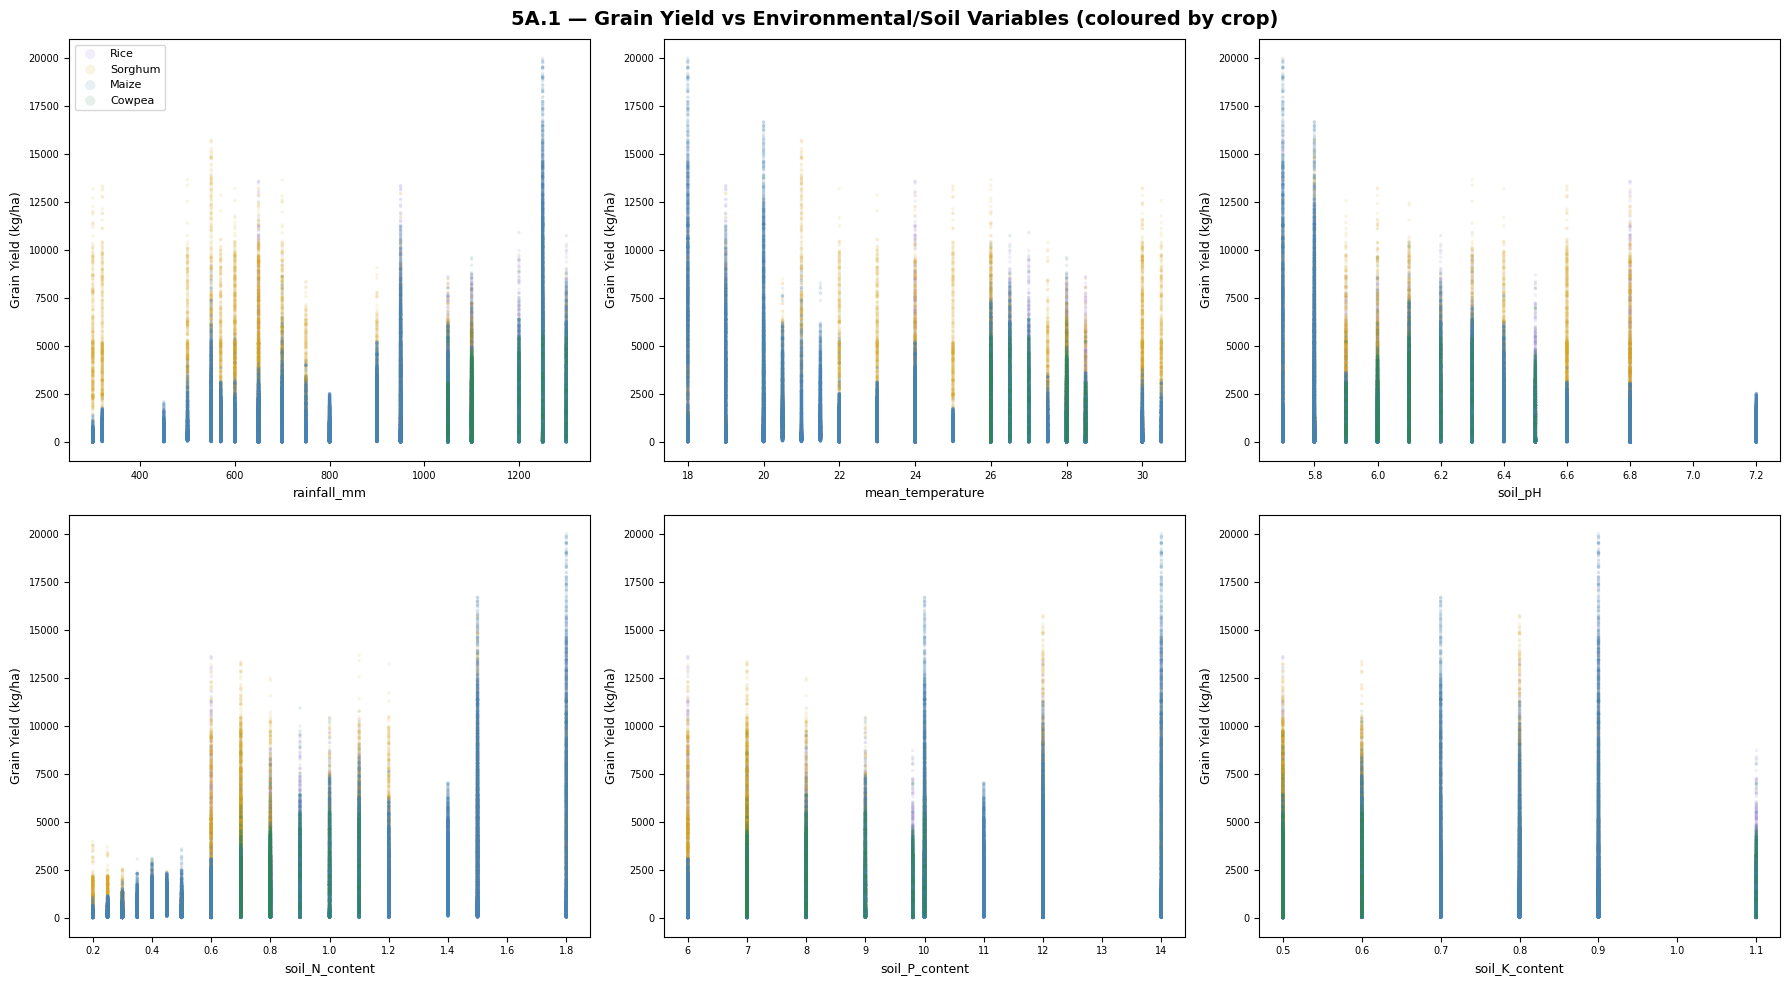

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('5A.1 — Grain Yield vs Environmental/Soil Variables (coloured by crop)',
             fontsize=14, fontweight='bold')

for i, var in enumerate(env_vars):
    ax = axes[i]
    for crop in df['Crop'].unique():
        sub = df[df['Crop'] == crop]
        ax.scatter(sub[var], sub['grain_yield'], alpha=0.12, s=6,
                   color=crop_palette[crop], label=crop, edgecolors='none')
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Grain Yield (kg/ha)', fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

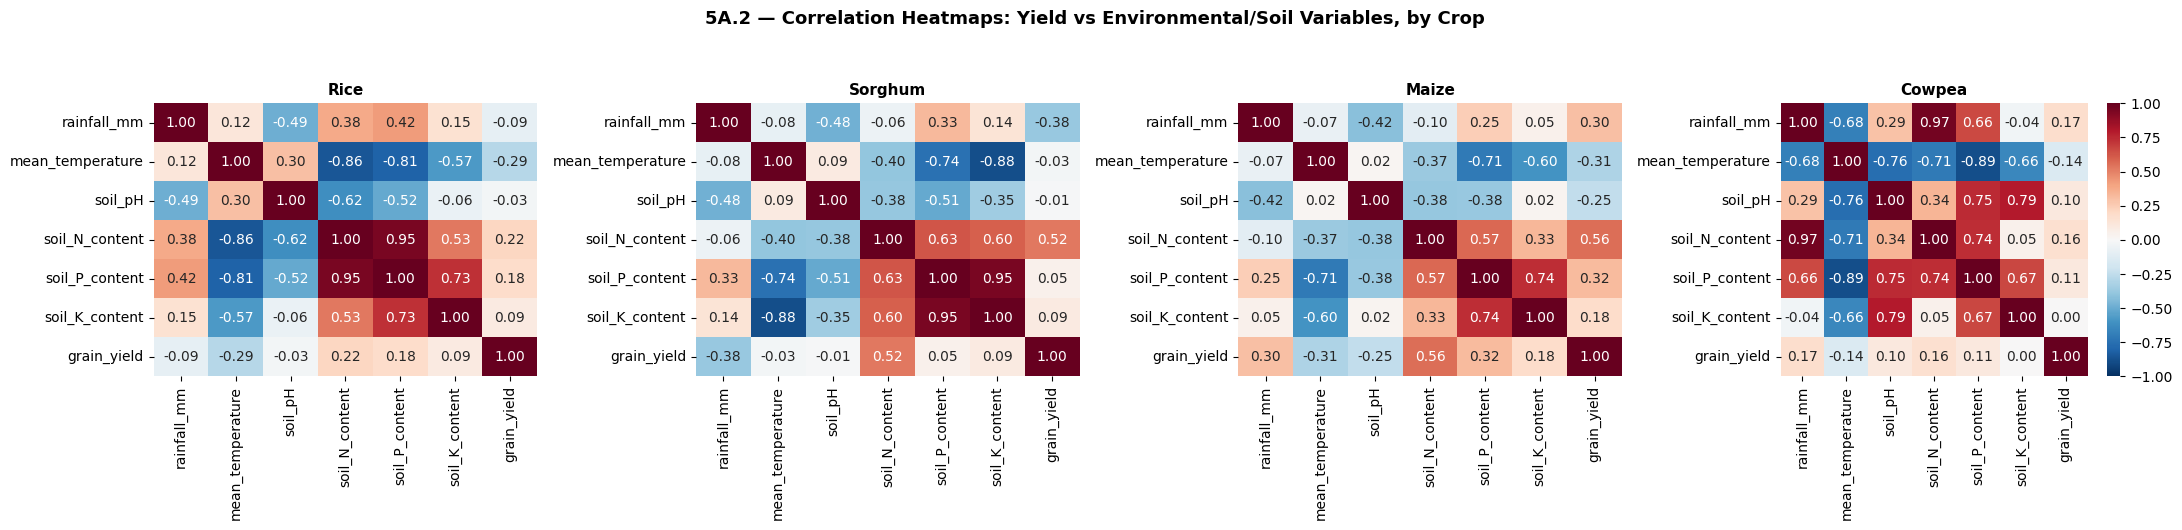

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, crop in enumerate(df['Crop'].unique()):
    sub = df[df['Crop'] == crop][env_vars + ['grain_yield']]
    corr = sub.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=axes[i], cbar=i == 3, vmin=-1, vmax=1)
    axes[i].set_title(crop, fontsize=11, fontweight='bold')
plt.suptitle('5A.2 — Correlation Heatmaps: Yield vs Environmental/Soil Variables, by Crop',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


5A.3 — PCA of Environmental/Soil Variables
PC1: 47.7% | PC2: 23.6% | Cumulative: 71.3%


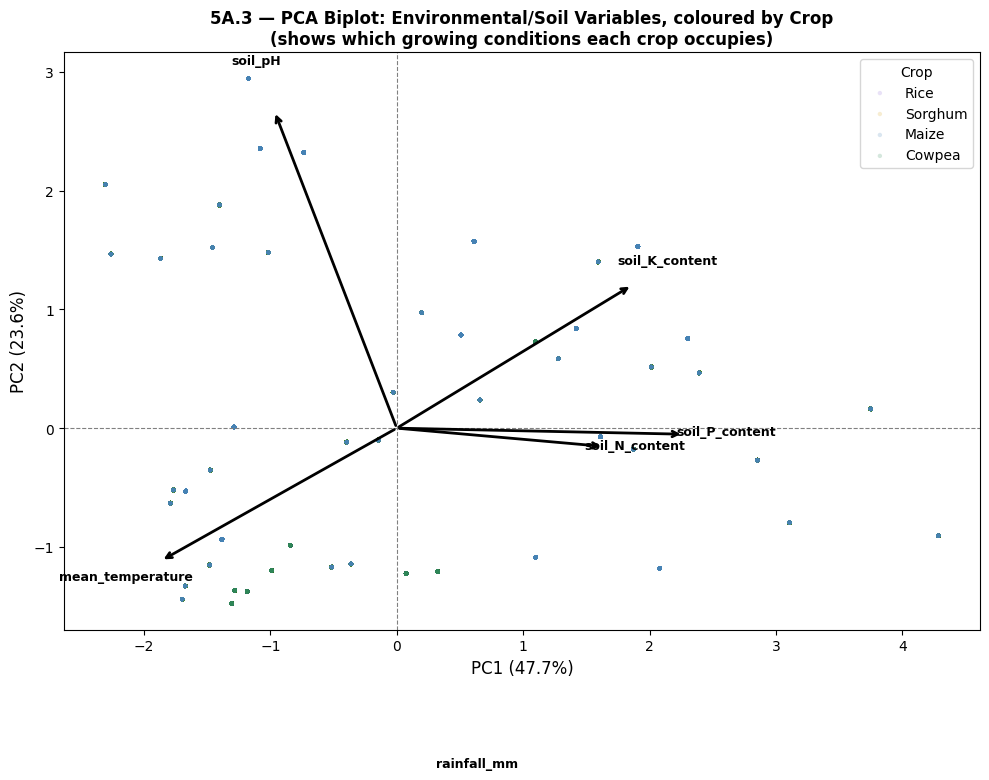

In [49]:
print("\n5A.3 — PCA of Environmental/Soil Variables")

pca_data = df[env_vars + ['Crop', 'grain_yield']].dropna()
X_pca_input = pca_data[env_vars]

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca_input)

pca_env = PCA()
X_pca_scores = pca_env.fit_transform(X_scaled_pca)
exp_var_env = pca_env.explained_variance_ratio_ * 100
print(f"PC1: {exp_var_env[0]:.1f}% | PC2: {exp_var_env[1]:.1f}% | "
      f"Cumulative: {exp_var_env[0]+exp_var_env[1]:.1f}%")

fig, ax = plt.subplots(figsize=(10, 8))
for crop in pca_data['Crop'].unique():
    mask = pca_data['Crop'].values == crop
    ax.scatter(X_pca_scores[mask, 0], X_pca_scores[mask, 1],
               color=crop_palette[crop], label=crop, alpha=0.2, s=10, edgecolors='none')

loadings_env = pca_env.components_.T
scale_env = 4
for j, var in enumerate(env_vars):
    ax.annotate('', xy=(loadings_env[j, 0]*scale_env, loadings_env[j, 1]*scale_env),
                xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(loadings_env[j, 0]*scale_env*1.15, loadings_env[j, 1]*scale_env*1.15,
            var, fontsize=9, fontweight='bold', ha='center')

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel(f'PC1 ({exp_var_env[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({exp_var_env[1]:.1f}%)', fontsize=12)
ax.set_title('5A.3 — PCA Biplot: Environmental/Soil Variables, coloured by Crop\n'
             '(shows which growing conditions each crop occupies)',
             fontsize=12, fontweight='bold')
ax.legend(title='Crop')
plt.tight_layout()
plt.show()

### 5B — Inferential Statistics

In [50]:
# ============================================================
#  5B — INFERENTIAL STATISTICS
# ============================================================
print("\n" + "-"*60)
print("5B — Inferential Statistics: Regression Comparison Across Crops")
print("-"*60)


------------------------------------------------------------
5B — Inferential Statistics: Regression Comparison Across Crops
------------------------------------------------------------



5B.1 — Multiple Linear Regression per Crop (explanatory power)

Rice: R² = 0.0955 | Adj R² = 0.0941 | F = 69.5 | n = 3960

Sorghum: R² = 0.4469 | Adj R² = 0.4466 | F = 1598.9 | n = 11880

Maize: R² = 0.5267 | Adj R² = 0.5267 | F = 13451.4 | n = 72521

Cowpea: R² = 0.0430 | Adj R² = 0.0406 | F = 17.9 | n = 2400

R² ranking — which crop's yield is BEST EXPLAINED by environment/soil:
   Crop     R2  Adj_R2     F_stat     n
  Maize 0.5267  0.5267 13451.4284 72521
Sorghum 0.4469  0.4466  1598.9461 11880
   Rice 0.0955  0.0941    69.5464  3960
 Cowpea 0.0430  0.0406    17.9255  2400


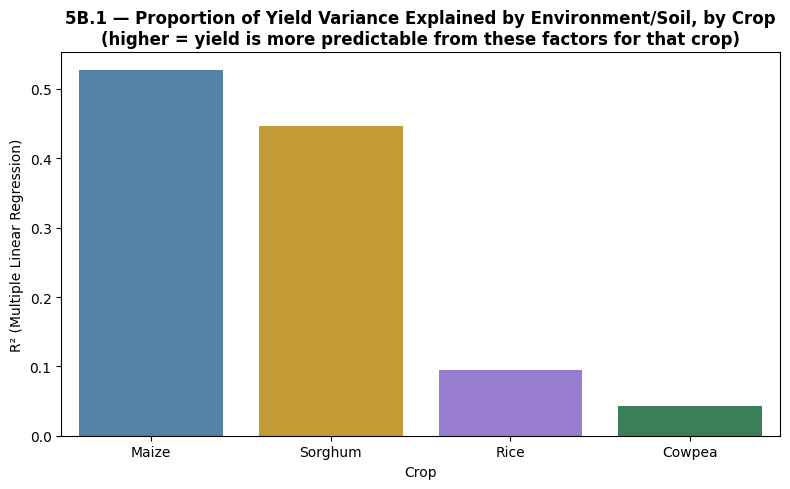

In [51]:
print("\n5B.1 — Multiple Linear Regression per Crop (explanatory power)")

mlr_results = {}
r2_summary = []

for crop in df['Crop'].unique():
    sub = df[df['Crop'] == crop][env_vars + ['grain_yield']].dropna()
    X = sub[env_vars]
    y = sub['grain_yield']
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()
    mlr_results[crop] = model
    r2_summary.append({'Crop': crop, 'R2': model.rsquared,
                        'Adj_R2': model.rsquared_adj, 'F_stat': model.fvalue,
                        'n': len(sub)})
    print(f"\n{crop}: R² = {model.rsquared:.4f} | Adj R² = {model.rsquared_adj:.4f} | "
          f"F = {model.fvalue:.1f} | n = {len(sub)}")

r2_df = pd.DataFrame(r2_summary).sort_values('R2', ascending=False)
print("\nR² ranking — which crop's yield is BEST EXPLAINED by environment/soil:")
print(r2_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=r2_df, x='Crop', y='R2', palette=crop_palette, ax=ax)
ax.set_title('5B.1 — Proportion of Yield Variance Explained by Environment/Soil, by Crop\n'
             '(higher = yield is more predictable from these factors for that crop)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('R² (Multiple Linear Regression)')
plt.tight_layout()
plt.show()

In [52]:
print("\n5B.2 — Multicollinearity (VIF) Check per Crop")
from statsmodels.stats.outliers_influence import variance_inflation_factor

for crop in df['Crop'].unique():
    sub = df[df['Crop'] == crop][env_vars].dropna()
    vif_data = pd.DataFrame()
    vif_data['Variable'] = env_vars
    vif_data['VIF'] = [variance_inflation_factor(sub.values, i) for i in range(len(env_vars))]
    print(f"\n{crop} VIF:")
    print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))


5B.2 — Multicollinearity (VIF) Check per Crop

Rice VIF:
        Variable         VIF
  soil_P_content 1354.770287
mean_temperature  524.138004
  soil_N_content  487.478405
         soil_pH  386.089397
     rainfall_mm  240.348765
  soil_K_content  121.677663

Sorghum VIF:
        Variable        VIF
  soil_K_content 651.450636
  soil_P_content 416.493862
         soil_pH 344.719259
mean_temperature 127.996925
     rainfall_mm  18.156289
  soil_N_content   9.489571

Maize VIF:
        Variable        VIF
         soil_pH 107.712326
  soil_P_content  76.377456
mean_temperature  61.942997
  soil_K_content  43.335413
     rainfall_mm  14.928433
  soil_N_content   8.299380

Cowpea VIF:
        Variable         VIF
         soil_pH 3890.325037
     rainfall_mm 3319.223323
mean_temperature 1441.257031
  soil_N_content 1177.160716
  soil_P_content  914.510026
  soil_K_content  147.236734



5B.3 — Standardised Sensitivity Comparison (which crop reacts most)

Standardised slope table:
   Crop         Variable  Standardised_slope  p-value
   Rice      rainfall_mm           -237.8212   0.0000
   Rice mean_temperature           -768.6168   0.0000
   Rice          soil_pH            -79.9381   0.0617
   Rice   soil_N_content            582.7688   0.0000
   Rice   soil_P_content            495.3788   0.0000
   Rice   soil_K_content            245.5219   0.0000
Sorghum      rainfall_mm          -1018.3908   0.0000
Sorghum mean_temperature            -73.9683   0.0027
Sorghum          soil_pH            -24.3817   0.3221
Sorghum   soil_N_content           1405.0276   0.0000
Sorghum   soil_P_content            138.7885   0.0000
Sorghum   soil_K_content            238.7572   0.0000
  Maize      rainfall_mm            615.9258   0.0000
  Maize mean_temperature           -626.2332   0.0000
  Maize          soil_pH           -503.3051   0.0000
  Maize   soil_N_content           1129.

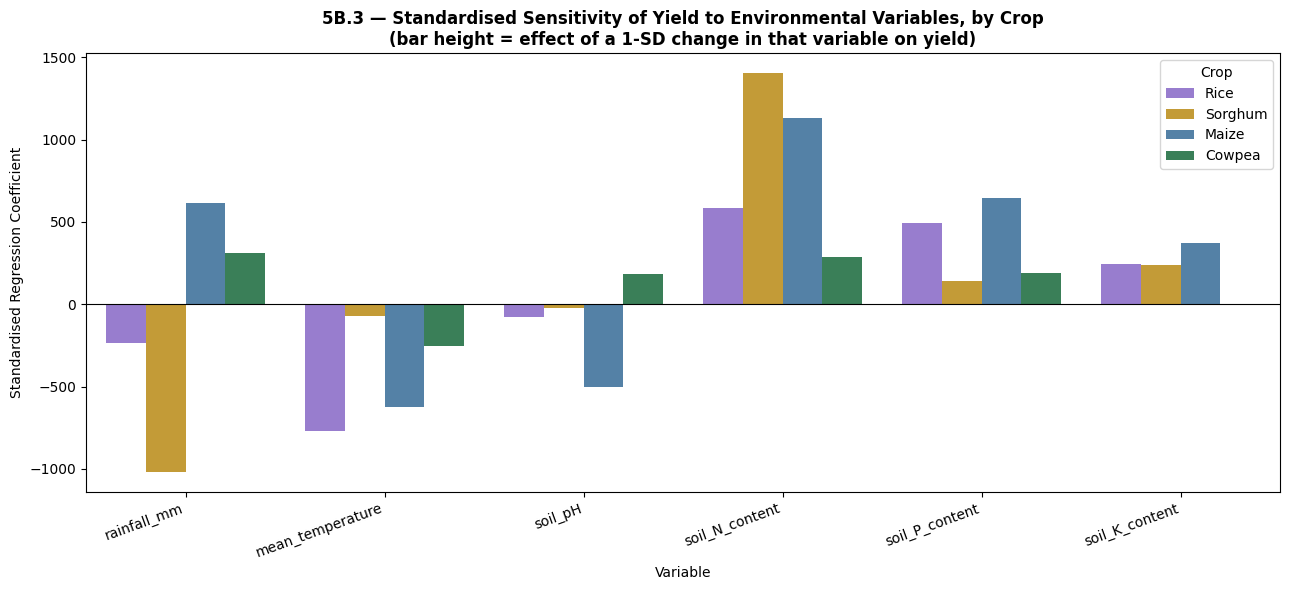

In [53]:
print("\n5B.3 — Standardised Sensitivity Comparison (which crop reacts most)")

sensitivity_std = []
for crop in df['Crop'].unique():
    sub = df[df['Crop'] == crop]
    for var in env_vars:
        data = sub[[var, 'grain_yield']].copy()
        data[var] = pd.to_numeric(data[var], errors='coerce')
        data['grain_yield'] = pd.to_numeric(data['grain_yield'], errors='coerce')
        data = data.dropna()
        if len(data) < 10:
            continue
        x = data[var].to_numpy(dtype=float)
        y = data['grain_yield'].to_numpy(dtype=float)
        x_std = (x - x.mean()) / x.std()
        slope_std, _, r, p, se = stats.linregress(x_std, y)
        sensitivity_std.append({'Crop': crop, 'Variable': var,
                                 'Standardised_slope': slope_std, 'p-value': p})

sensitivity_std_df = pd.DataFrame(sensitivity_std)
print("\nStandardised slope table:")
print(sensitivity_std_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=sensitivity_std_df, x='Variable', y='Standardised_slope', hue='Crop',
            palette=crop_palette, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('5B.3 — Standardised Sensitivity of Yield to Environmental Variables, by Crop\n'
             '(bar height = effect of a 1-SD change in that variable on yield)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Standardised Regression Coefficient')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [54]:
overall_sensitivity = sensitivity_std_df.groupby('Crop')['Standardised_slope'].apply(
    lambda x: x.abs().mean()
).sort_values(ascending=False)
print("\nOverall sensitivity ranking (mean absolute standardised slope across all variables):")
print(overall_sensitivity.round(4))
print("\n(Highest = most responsive to environmental/soil changes overall)")


Overall sensitivity ranking (mean absolute standardised slope across all variables):
Crop
Maize      648.8823
Sorghum    483.2190
Rice       401.6743
Cowpea     204.4515
Name: Standardised_slope, dtype: float64

(Highest = most responsive to environmental/soil changes overall)



--- 5B.5 — Overall Variable Importance (across all crops) ---

Mean |standardised slope| per variable, averaged across all 4 crops:
Variable
soil_N_content      851.8533
rainfall_mm         545.1750
mean_temperature    430.3007
soil_P_content      367.4045
soil_K_content      214.4184
soil_pH             198.1888
Name: Standardised_slope, dtype: float64

(Highest = most important environmental/soil driver of yield overall; lowest = least important)


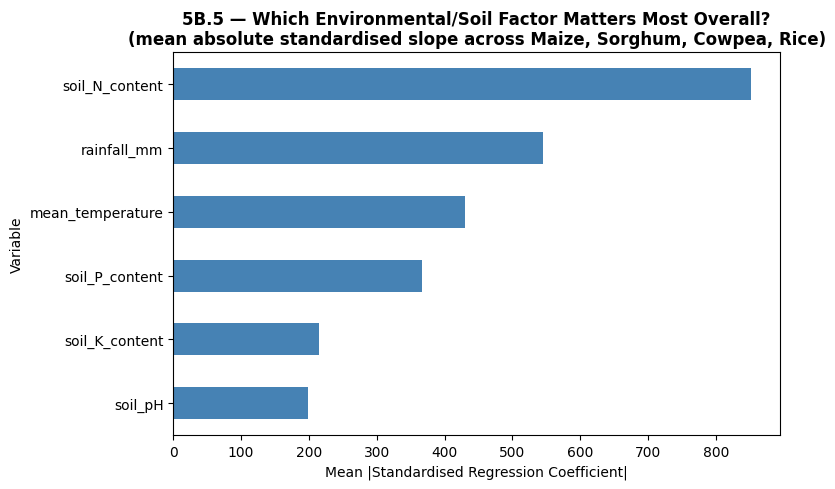


Top environmental driver, per crop:
  Rice      : mean_temperature   (slope = -768.617, p = 3.44e-75)
  Sorghum   : soil_N_content     (slope = 1405.028, p = 0)
  Maize     : soil_N_content     (slope = 1129.856, p = 0)
  Cowpea    : rainfall_mm        (slope = 308.562, p = 7.54e-18)


In [55]:
print("\n--- 5B.5 — Overall Variable Importance (across all crops) ---")

var_importance = sensitivity_std_df.groupby('Variable')['Standardised_slope'].apply(
    lambda x: x.abs().mean()
).sort_values(ascending=False)

print("\nMean |standardised slope| per variable, averaged across all 4 crops:")
print(var_importance.round(4))
print("\n(Highest = most important environmental/soil driver of yield overall; "
      "lowest = least important)")

fig, ax = plt.subplots(figsize=(8, 5))
var_importance.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('5B.5 — Which Environmental/Soil Factor Matters Most Overall?\n'
             '(mean absolute standardised slope across Maize, Sorghum, Cowpea, Rice)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |Standardised Regression Coefficient|')
plt.tight_layout()
plt.show()

# Per-crop top driver — lets us say "X matters most for Maize but Y for Sorghum"
print("\nTop environmental driver, per crop:")
for crop in sensitivity_std_df['Crop'].unique():
    sub = sensitivity_std_df[sensitivity_std_df['Crop'] == crop].copy()
    sub['abs_slope'] = sub['Standardised_slope'].abs()
    top_var = sub.sort_values('abs_slope', ascending=False).iloc[0]
    print(f"  {crop:<10}: {top_var['Variable']:<18} "
          f"(slope = {top_var['Standardised_slope']:.3f}, p = {top_var['p-value']:.3g})")

### 5C — GGE Biplots (Genotype + Genotype-by-Environment Interaction)

Builds a genotype × environment mean-yield matrix for each crop, centres it by environment (removing the environment main effect to isolate Genotype + GxE), and runs PCA to visualise which genotypes perform best in which environments — the standard approach for multi-environment trial analysis in plant breeding.


------------------------------------------------------------
5C — GGE Biplots: Genotype Stability Across Environments
------------------------------------------------------------

GGE Biplots — Maize and Sorghum (Country x Management environments)

Maize GGE Biplot (Country_Management): PC1 = 71.7%, PC2 = 9.6%, Cumulative = 81.4%
Genotypes: 237 | Environments: 15


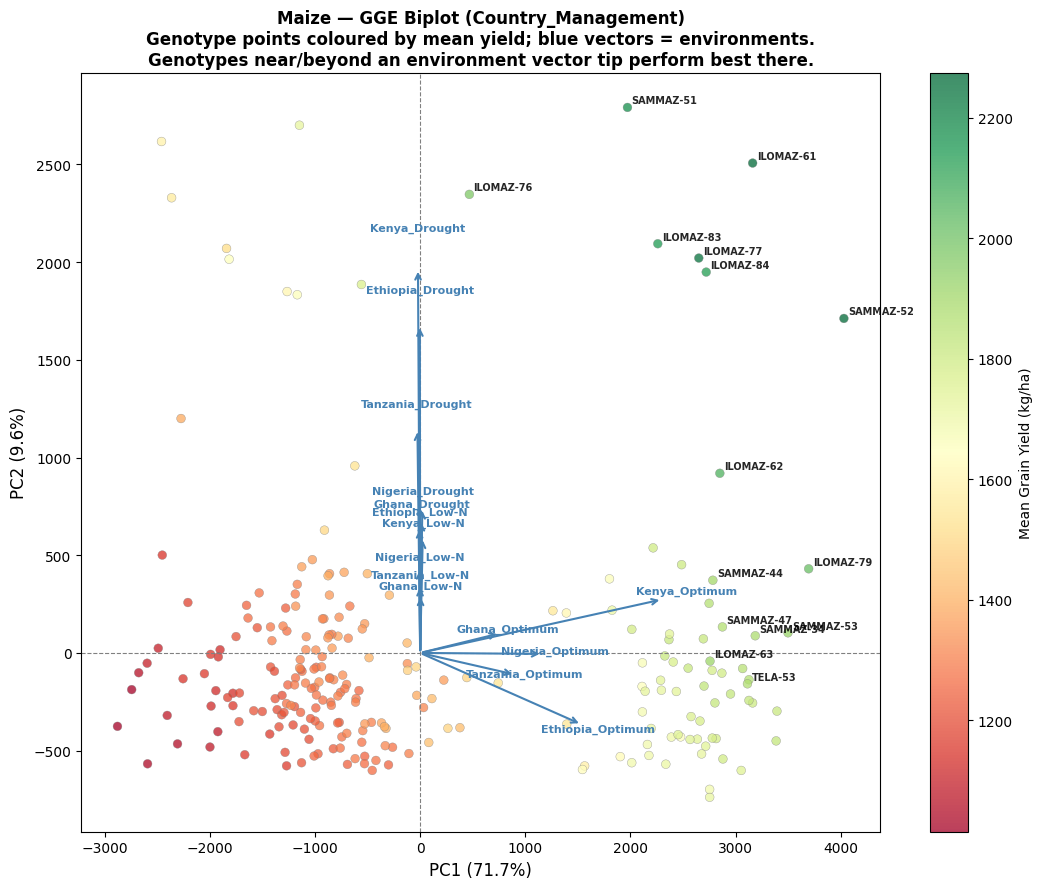


Sorghum GGE Biplot (Country_Management): PC1 = 94.4%, PC2 = 1.7%, Cumulative = 96.1%
Genotypes: 60 | Environments: 12


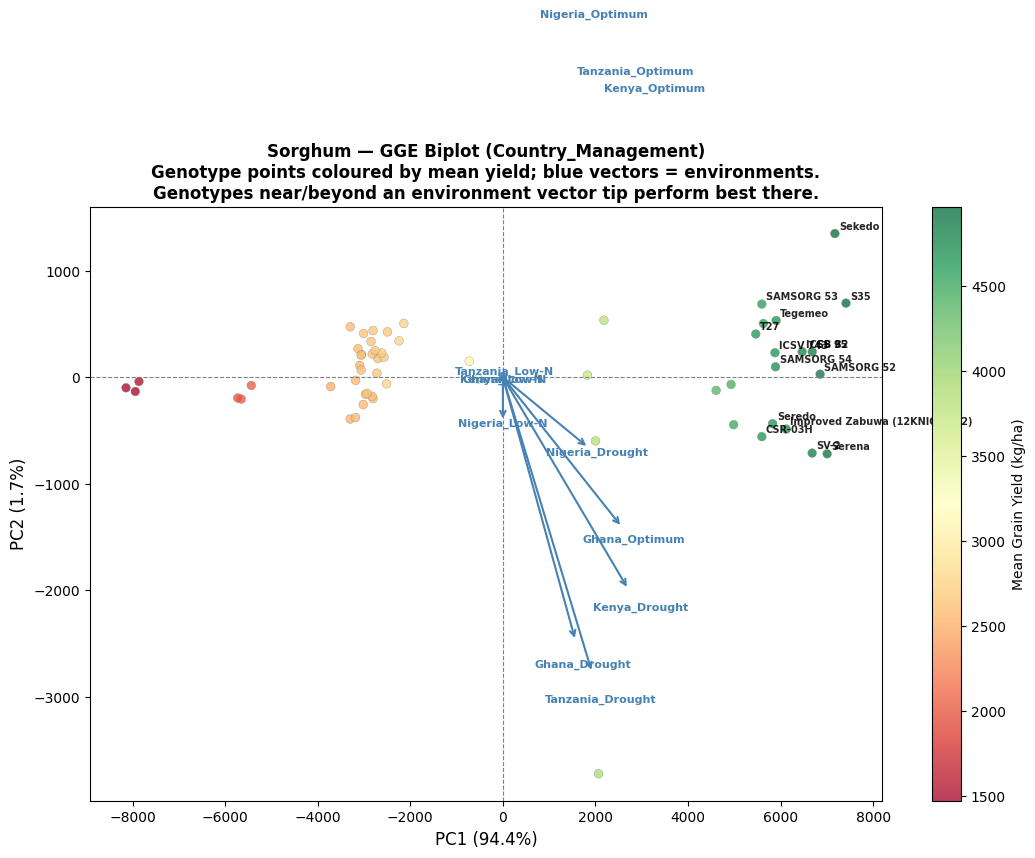


GGE Biplots — Rice and Cowpea (Country x Year environments)
Note: Rice and Cowpea were trialled under Optimum management only, so Country x Management would yield too few/degenerate environments (3 and 2 respectively). Country x Year is used instead to provide a genuinely informative number of environments (9 for Rice, 6 for Cowpea).

Rice GGE Biplot (Country_Year): PC1 = 67.6%, PC2 = 12.0%, Cumulative = 79.6%
Genotypes: 60 | Environments: 9


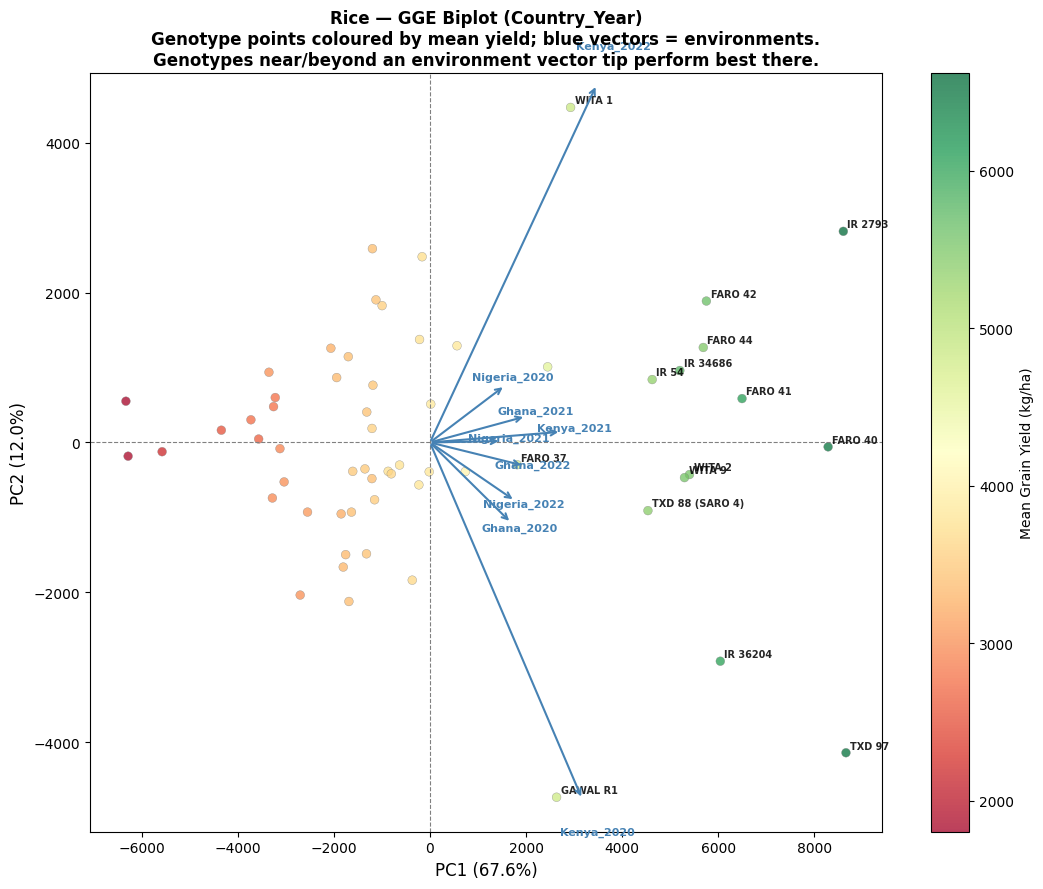


Cowpea GGE Biplot (Country_Year): PC1 = 69.5%, PC2 = 9.4%, Cumulative = 78.9%
Genotypes: 50 | Environments: 6


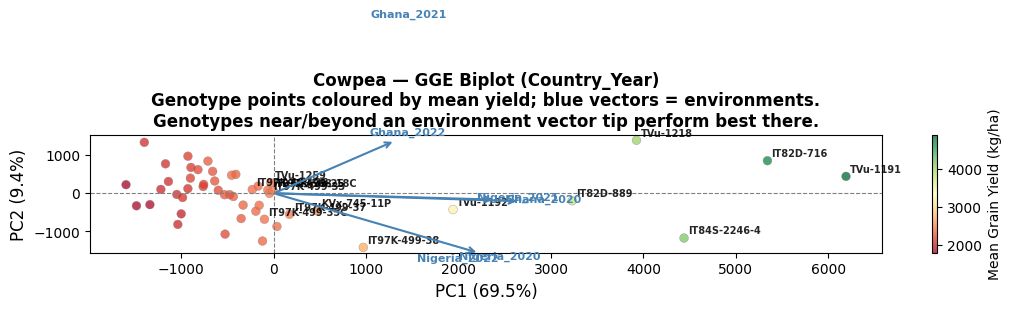


Section 5 (Cross-crop comparison) complete.


In [56]:
# ============================================================
#  5C — GGE BIPLOTS (Genotype + Genotype-by-Environment)
# ============================================================
print("\n" + "-"*60)
print("5C — GGE Biplots: Genotype Stability Across Environments")
print("-"*60)

def gge_biplot(data, crop_name, env_definition='Country_Management', top_label_n=15):
    """
    Builds a genotype x environment yield matrix and runs PCA on it
    (the standard approach behind GGE biplots: Genotype + GE interaction).

    env_definition: how 'environment' is defined for this biplot.
        'Country_Management' -> each Country x Management combo is one environment
                                 (only meaningful for crops with multiple management
                                 conditions, i.e. Maize and Sorghum)
        'Country_Year'       -> each Country x Year combo is one environment
                                 (used for Rice and Cowpea, which were trialled only
                                 under Optimum management, so Management cannot
                                 serve as a source of environmental variation there)
        'Region_Management'  -> each Region x Management combo is one environment
    """
    d = data.copy()

    if env_definition == 'Country_Management':
        d['Environment'] = d['Country'] + '_' + d['environment_condition']
    elif env_definition == 'Country_Year':
        d['Environment'] = d['Country'] + '_' + d['YEAR'].astype(str)
    elif env_definition == 'Region_Management':
        d['Environment'] = d['region'] + '_' + d['environment_condition']
    else:
        raise ValueError("Unknown env_definition")

    # Genotype x Environment matrix of mean yield
    ge_matrix = d.groupby(['Name', 'Environment'])['grain_yield'].mean().unstack()

    # GGE biplots conventionally use environment-centred data (centring by
    # environment removes the environment main effect, leaving Genotype + GxE)
    ge_centred = ge_matrix.sub(ge_matrix.mean(axis=0), axis=1)
    ge_centred = ge_centred.dropna(axis=1, how='any')  # keep complete environments only

    if ge_centred.shape[1] < 2:
        print(f"Not enough complete environments for {crop_name} with "
              f"{env_definition} ({ge_centred.shape[1]} found) — "
              f"try a different env_definition.")
        return None, None

    pca = PCA(n_components=2)
    geno_scores = pca.fit_transform(ge_centred.values)
    env_loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100

    print(f"\n{crop_name} GGE Biplot ({env_definition}): "
          f"PC1 = {exp_var[0]:.1f}%, PC2 = {exp_var[1]:.1f}%, "
          f"Cumulative = {exp_var.sum():.1f}%")
    print(f"Genotypes: {ge_centred.shape[0]} | Environments: {ge_centred.shape[1]}")

    overall_mean = ge_matrix.mean(axis=1)

    fig, ax = plt.subplots(figsize=(11, 9))

    sc = ax.scatter(geno_scores[:, 0], geno_scores[:, 1],
                     c=overall_mean.reindex(ge_centred.index).values,
                     cmap='RdYlGn', s=40, alpha=0.75, edgecolors='grey', linewidths=0.3)
    plt.colorbar(sc, ax=ax, label='Mean Grain Yield (kg/ha)')

    top_genos = overall_mean.reindex(ge_centred.index).sort_values(ascending=False).head(top_label_n)
    for name in top_genos.index:
        idx = ge_centred.index.get_loc(name)
        ax.annotate(name, (geno_scores[idx, 0], geno_scores[idx, 1]),
                    fontsize=7, fontweight='bold', alpha=0.85,
                    xytext=(3, 3), textcoords='offset points')

    scale = np.max(np.abs(geno_scores)) * 0.8
    for j, env in enumerate(ge_centred.columns):
        ax.annotate('', xy=(env_loadings[j, 0]*scale, env_loadings[j, 1]*scale),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
        ax.text(env_loadings[j, 0]*scale*1.1, env_loadings[j, 1]*scale*1.1,
                env, fontsize=8, color='steelblue', fontweight='bold', ha='center')

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'PC1 ({exp_var[0]:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({exp_var[1]:.1f}%)', fontsize=12)
    ax.set_title(f'{crop_name} — GGE Biplot ({env_definition})\n'
                 'Genotype points coloured by mean yield; blue vectors = environments.\n'
                 'Genotypes near/beyond an environment vector tip perform best there.',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return ge_matrix, pca


print("\nGGE Biplots — Maize and Sorghum (Country x Management environments)")
maize = df[df['Crop'] == 'Maize'].copy()
sorghum = df[df['Crop'] == 'Sorghum'].copy()

maize_ge_matrix, maize_pca = gge_biplot(maize, 'Maize', env_definition='Country_Management')
sorghum_ge_matrix, sorghum_pca = gge_biplot(sorghum, 'Sorghum', env_definition='Country_Management')

print("\nGGE Biplots — Rice and Cowpea (Country x Year environments)")
print("Note: Rice and Cowpea were trialled under Optimum management only, so "
      "Country x Management would yield too few/degenerate environments "
      "(3 and 2 respectively). Country x Year is used instead to provide a "
      "genuinely informative number of environments (9 for Rice, 6 for Cowpea).")
rice = df[df['Crop'] == 'Rice'].copy()
cowpea = df[df['Crop'] == 'Cowpea'].copy()

rice_ge_matrix, rice_pca = gge_biplot(rice, 'Rice', env_definition='Country_Year')
cowpea_ge_matrix, cowpea_pca = gge_biplot(cowpea, 'Cowpea', env_definition='Country_Year')

print("\nSection 5 (Cross-crop comparison) complete.")

## Section 6 — Interactive Variety Selection Dashboard

> **AI prompt used:** *"Using the genotype cluster tables built in Sections 2–4, build a lookup table of mean yield for every Crop × Country × Region × Management × Genotype combination. Then create an interactive widget — using ipywidgets dropdowns for Crop, Country, Region, and Management Condition — that returns the top 5 highest-yielding genotypes for the selected combination, so a user can identify the best available variety for any given location and management scenario without writing any code."*


In [57]:
# ── Build the master lookup table ────────────────────────────────────
# Combines Crop x Country x Region x Management x Genotype mean yield
# across the full dataset, for interactive querying below.

dashboard_table = (
    df.groupby(['Crop', 'Country', 'region', 'environment_condition', 'Name'])['grain_yield']
      .mean()
      .reset_index()
      .rename(columns={'region': 'Region', 'environment_condition': 'Management', 'Name': 'Genotype'})
)

print(f"Dashboard lookup table built: {dashboard_table.shape[0]:,} rows")
dashboard_table.head()

Dashboard lookup table built: 15,127 rows


,Crop,Country,Region,Management,Genotype,grain_yield
0,Cowpea,Ghana,Damongo,Optimum,IT82D-716,3981.493051
1,Cowpea,Ghana,Damongo,Optimum,IT82D-889,4583.678066
2,Cowpea,Ghana,Damongo,Optimum,IT84S-2246-4,5805.484344
3,Cowpea,Ghana,Damongo,Optimum,IT84S-2246-5,2392.972586
4,Cowpea,Ghana,Damongo,Optimum,IT84S-2246-6,2122.329684


In [58]:
# ── Interactive widget: best genotype finder ─────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

crop_dropdown = widgets.Dropdown(options=sorted(dashboard_table['Crop'].unique()), description='Crop:')
country_dropdown = widgets.Dropdown(description='Country:')
region_dropdown = widgets.Dropdown(description='Region:')
management_dropdown = widgets.Dropdown(description='Management:')
output = widgets.Output()

def update_country_options(*args):
    crop = crop_dropdown.value
    options = sorted(dashboard_table.loc[dashboard_table['Crop'] == crop, 'Country'].unique())
    country_dropdown.options = options

def update_region_options(*args):
    crop, country = crop_dropdown.value, country_dropdown.value
    sub = dashboard_table[(dashboard_table['Crop'] == crop) & (dashboard_table['Country'] == country)]
    region_dropdown.options = sorted(sub['Region'].unique())

def update_management_options(*args):
    crop, country, region = crop_dropdown.value, country_dropdown.value, region_dropdown.value
    sub = dashboard_table[(dashboard_table['Crop'] == crop) & (dashboard_table['Country'] == country)
                           & (dashboard_table['Region'] == region)]
    management_dropdown.options = sorted(sub['Management'].unique())

def show_top_genotypes(*args):
    with output:
        clear_output()
        crop, country, region, mgmt = (crop_dropdown.value, country_dropdown.value,
                                        region_dropdown.value, management_dropdown.value)
        sub = dashboard_table[(dashboard_table['Crop'] == crop) & (dashboard_table['Country'] == country)
                               & (dashboard_table['Region'] == region) & (dashboard_table['Management'] == mgmt)]
        top5 = sub.sort_values('grain_yield', ascending=False).head(5)
        print(f"Top 5 genotypes — {crop}, {country}, {region}, {mgmt}:\n")
        print(top5[['Genotype', 'grain_yield']].rename(columns={'grain_yield': 'Mean Yield (kg/ha)'})
              .to_string(index=False))

crop_dropdown.observe(update_country_options, 'value')
country_dropdown.observe(update_region_options, 'value')
region_dropdown.observe(update_management_options, 'value')
management_dropdown.observe(show_top_genotypes, 'value')

update_country_options()
update_region_options()
update_management_options()

display(widgets.VBox([crop_dropdown, country_dropdown, region_dropdown, management_dropdown, output]))
show_top_genotypes()